# Introdução

Neste notebook será feita uma analise exploratória dos dados para entender nulos, relações entre variáveis e características acerca dos dados

In [1]:
import pandas as pd
import duckdb
from discovery import DataDiscovery

# Análises exploratórias

## Cadastro

In [2]:
df_base_cadastral = pd.read_parquet('data/base_cadastral.parquet')

In [3]:
df_base_cadastral.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  40000 non-null  int64  
 1   sexo                        40000 non-null  object 
 2   data_nascimento             40000 non-null  object 
 3   qtd_filhos                  40000 non-null  int64  
 4   qtd_membros_familia         40000 non-null  float64
 5   renda_anual                 40000 non-null  float64
 6   tipo_renda                  40000 non-null  object 
 7   ocupacao                    27324 non-null  object 
 8   tipo_organizacao            40000 non-null  object 
 9   nivel_educacao              40000 non-null  object 
 10  estado_civil                40000 non-null  object 
 11  tipo_moradia                40000 non-null  object 
 12  possui_carro                40000 non-null  object 
 13  possui_imovel               400

In [4]:
df_base_cadastral.columns

Index(['id_cliente', 'sexo', 'data_nascimento', 'qtd_filhos',
       'qtd_membros_familia', 'renda_anual', 'tipo_renda', 'ocupacao',
       'tipo_organizacao', 'nivel_educacao', 'estado_civil', 'tipo_moradia',
       'possui_carro', 'possui_imovel', 'nota_regiao_cliente',
       'nota_regiao_cliente_cidade'],
      dtype='object')

In [5]:
# abaixo será verificado para soft nulls e nulos reais
DataDiscovery(df_base_cadastral).verify_null()

"Column 'ocupacao': 12676 soft null(s) found → [None]"

In [6]:
df_base_cadastral.head()

,id_cliente,sexo,data_nascimento,qtd_filhos,qtd_membros_familia,renda_anual,tipo_renda,ocupacao,tipo_organizacao,nivel_educacao,estado_civil,tipo_moradia,possui_carro,possui_imovel,nota_regiao_cliente,nota_regiao_cliente_cidade
0,100023,F,1994-01-30,1,2.0,90000.0,State servant,Core staff,Kindergarten,Higher education,Single / not married,House / apartment,N,Y,2,2
1,100031,F,1973-11-13,0,1.0,112500.0,Working,Cooking staff,Business Entity Type 3,Secondary / secondary special,Widow,House / apartment,N,Y,3,2
2,100056,M,1975-02-19,0,2.0,360000.0,Working,Laborers,Transport: type 2,Secondary / secondary special,Married,House / apartment,Y,Y,2,2
3,100069,M,1986-04-10,1,2.0,360000.0,Working,Laborers,Transport: type 4,Secondary / secondary special,Separated,House / apartment,Y,Y,2,2
4,100085,M,1994-07-05,1,3.0,157500.0,Working,Drivers,Business Entity Type 1,Secondary / secondary special,Married,House / apartment,N,Y,2,2


In [7]:
output = DataDiscovery(df_base_cadastral).continuos_analytics(['qtd_filhos','qtd_membros_familia',
                                                      'renda_anual','nota_regiao_cliente',
                                                      'nota_regiao_cliente_cidade'])
print(output)

Column 'qtd_filhos':
  Mean: 0.413225
  Median: 0.0
  Std Dev: 0.7180062588165179
  Min: 0.0
  1%: 0.0
  5%: 0.0
  10%: 0.0
  20%: 0.0
  25%: 0.0
  50%: 0.0
  75%: 1.0
  80%: 1.0
  90%: 1.0
  95%: 2.0
  99%: 3.0
  Max: 14.0

Column 'qtd_membros_familia':
  Mean: 2.153175
  Median: 2.0
  Std Dev: 0.9036220629753444
  Min: 1.0
  1%: 1.0
  5%: 1.0
  10%: 1.0
  20%: 1.0
  25%: 2.0
  50%: 2.0
  75%: 3.0
  80%: 3.0
  90%: 3.0
  95%: 4.0
  99%: 5.0
  Max: 15.0

Column 'renda_anual':
  Mean: 172853.865016875
  Median: 148500.0
  Std Dev: 602510.2301467977
  Min: 26100.0
  1%: 45000.0
  5%: 67500.0
  10%: 81000.0
  20%: 99000.0
  25%: 112500.0
  50%: 148500.0
  75%: 202500.0
  80%: 225000.0
  90%: 270000.0
  95%: 337500.0
  99%: 495000.0
  Max: 117000000.0

Column 'nota_regiao_cliente':
  Mean: 2.051475
  Median: 2.0
  Std Dev: 0.5092954043776784
  Min: 1.0
  1%: 1.0
  5%: 1.0
  10%: 1.0
  20%: 2.0
  25%: 2.0
  50%: 2.0
  75%: 2.0
  80%: 2.0
  90%: 3.0
  95%: 3.0
  99%: 3.0
  Max: 3.0

Column '

In [8]:
output = DataDiscovery(df_base_cadastral).categorical_analytics(['sexo', 'tipo_renda', 'ocupacao',
                                                               'tipo_organizacao', 'nivel_educacao', 
                                                                 'estado_civil', 'tipo_moradia',
                                                               'possui_carro', 'possui_imovel'])
print(output)

Column 'sexo':
  Total Count: 40000
  Distinct Categories: 2
  Category Frequencies:
    'F': 26273 (65.68%)
    'M': 13727 (34.32%)

Column 'tipo_renda':
  Total Count: 40000
  Distinct Categories: 8
  Category Frequencies:
    'Working': 20502 (51.25%)
    'Commercial associate': 9251 (23.13%)
    'Pensioner': 7380 (18.45%)
    'State servant': 2858 (7.14%)
    'Unemployed': 3 (0.01%)
    'Maternity leave': 3 (0.01%)
    'Student': 2 (0.01%)
    'Businessman': 1 (0.00%)

Column 'ocupacao':
  Total Count: 40000
  Distinct Categories: 19
  Category Frequencies:
    'None': 12676 (31.69%)
    'Laborers': 7083 (17.71%)
    'Sales staff': 4190 (10.47%)
    'Core staff': 3501 (8.75%)
    'Managers': 2763 (6.91%)
    'Drivers': 2399 (6.00%)
    'High skill tech staff': 1532 (3.83%)
    'Accountants': 1261 (3.15%)
    'Medicine staff': 1086 (2.71%)
    'Security staff': 915 (2.29%)
    'Cooking staff': 753 (1.88%)
    'Cleaning staff': 585 (1.46%)
    'Private service staff': 360 (0.90%)
   


  ANÁLISE DE DATA: data_nascimento
  Registros válidos : 40,000
  Período           : 1956-02-16 → 2004-03-10


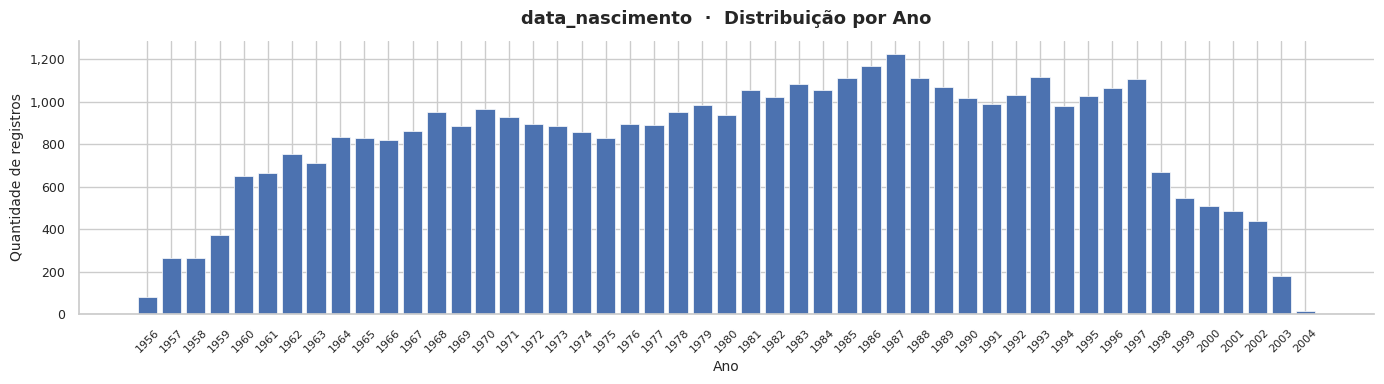

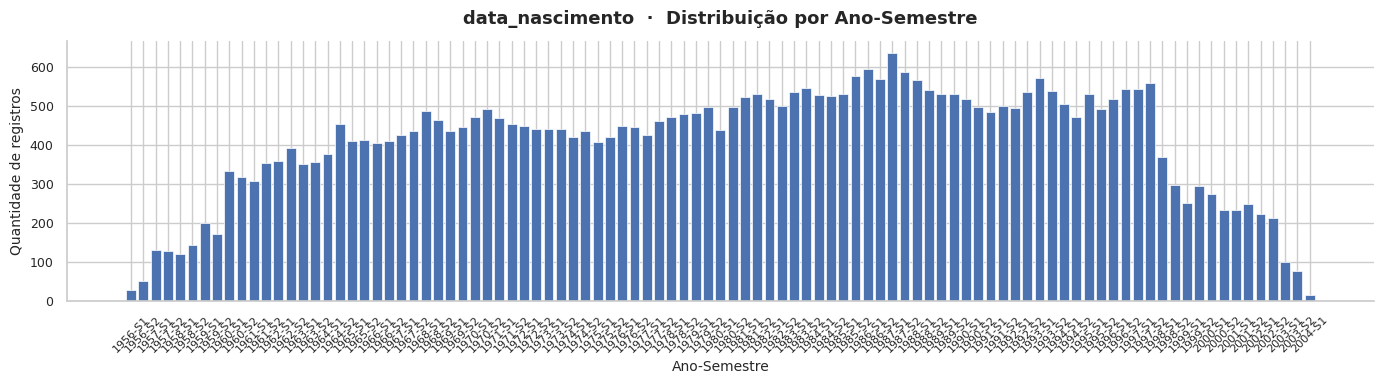

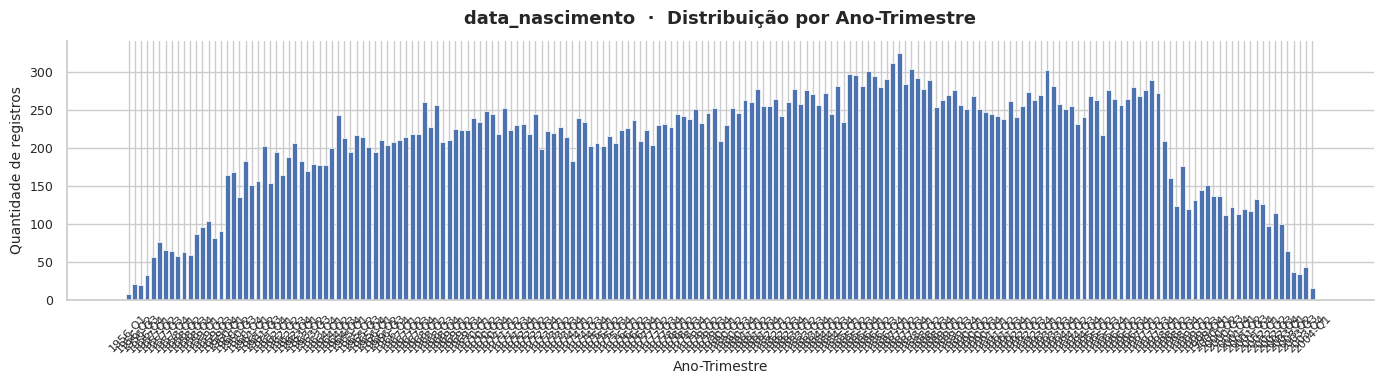

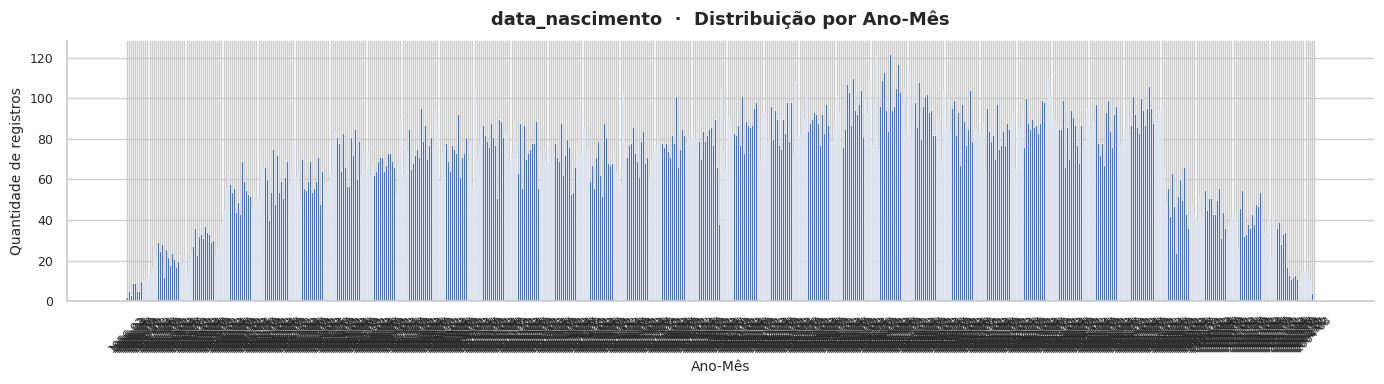

In [9]:
DataDiscovery(df_base_cadastral).date_analytics(['data_nascimento'])

Nao serão usadas informações sensíveis que possam induzir a discriminação. Então sexo e data_nascimento serão descartadas do modelo.
Nesse sentido, embora sexo e data de nascimento possam eventualmente apresentar correlação estatística com o evento-alvo do modelo, sua utilização introduziria risco de viés discriminatório sistêmico, penalizando ou beneficiando indivíduos com base em características protegidas por lei e não em seu comportamento financeiro efetivo. Tal prática violaria diretamente os princípios da LGPD e os direitos fundamentais assegurados pela Constituição Federal.

## base submissao

In [10]:
df_base_sub = pd.read_parquet('data/base_submissao.parquet')

In [11]:
df_base_sub.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              40000 non-null  int64  
 1   data_solicitacao        40000 non-null  object 
 2   dia_semana_solicitacao  40000 non-null  object 
 3   hora_solicitacao        40000 non-null  int64  
 4   tipo_contrato           40000 non-null  object 
 5   valor_credito           40000 non-null  float64
 6   valor_bem               39976 non-null  float64
 7   valor_parcela           39996 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 2.4+ MB


Abaixo pode-se ver que não tem softs nulls e algumas linhas que estão com as colunas valor_bem e valor_parcela null. Nota-se ainda que todo valor parcela com nan é tipo_contrato cashloans.

In [12]:
print(DataDiscovery(df_base_sub).verify_null())

Column 'valor_bem': 24 soft null(s) found → [nan]
Column 'valor_parcela': 4 soft null(s) found → [nan]


In [13]:
df_base_sub[df_base_sub['valor_bem'].isnull() | df_base_sub['valor_parcela'].isnull()]

,id_cliente,data_solicitacao,dia_semana_solicitacao,hora_solicitacao,tipo_contrato,valor_credito,valor_bem,valor_parcela
6027,162615,2025-02-05,WEDNESDAY,14,Revolving loans,270000.0,NaN,13500.0
7067,173434,2025-02-04,TUESDAY,13,Revolving loans,675000.0,NaN,33750.0
8804,191700,2025-02-15,SATURDAY,12,Revolving loans,270000.0,NaN,13500.0
9555,199789,2025-02-21,FRIDAY,14,Revolving loans,135000.0,NaN,6750.0
9985,204141,2025-02-21,FRIDAY,14,Revolving loans,202500.0,NaN,10125.0
12794,232572,2025-02-11,TUESDAY,18,Revolving loans,1237500.0,NaN,61875.0
13868,243648,2025-02-15,SATURDAY,12,Cash loans,929088.0,720000.0,NaN
14590,250439,2025-02-11,TUESDAY,11,Revolving loans,180000.0,NaN,9000.0
14837,252707,2025-02-22,SATURDAY,11,Revolving loans,157500.0,NaN,7875.0
15134,255767,2025-02-18,TUESDAY,12,Revolving loans,180000.0,NaN,9000.0



  ANÁLISE DE DATA: data_solicitacao
  Registros válidos : 40,000
  Período           : 2025-02-04 → 2025-02-24


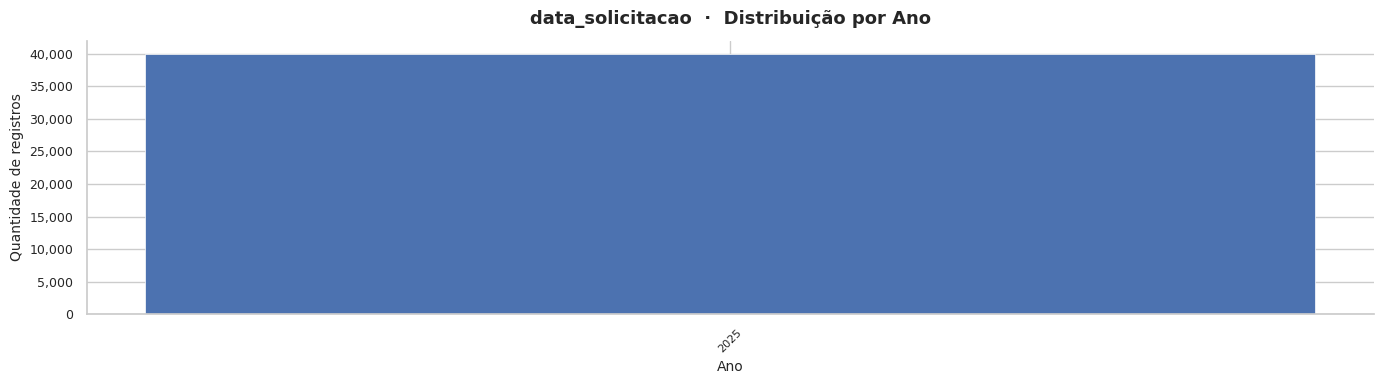

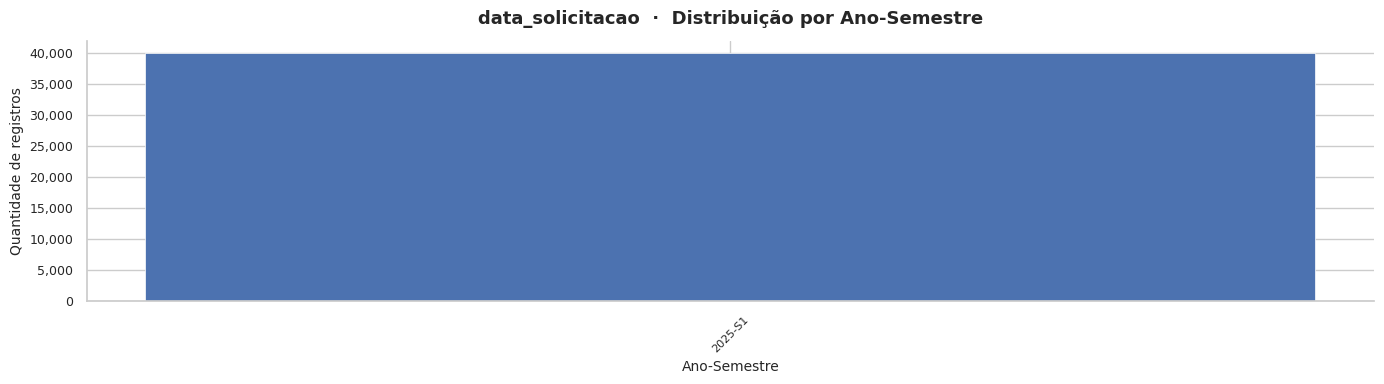

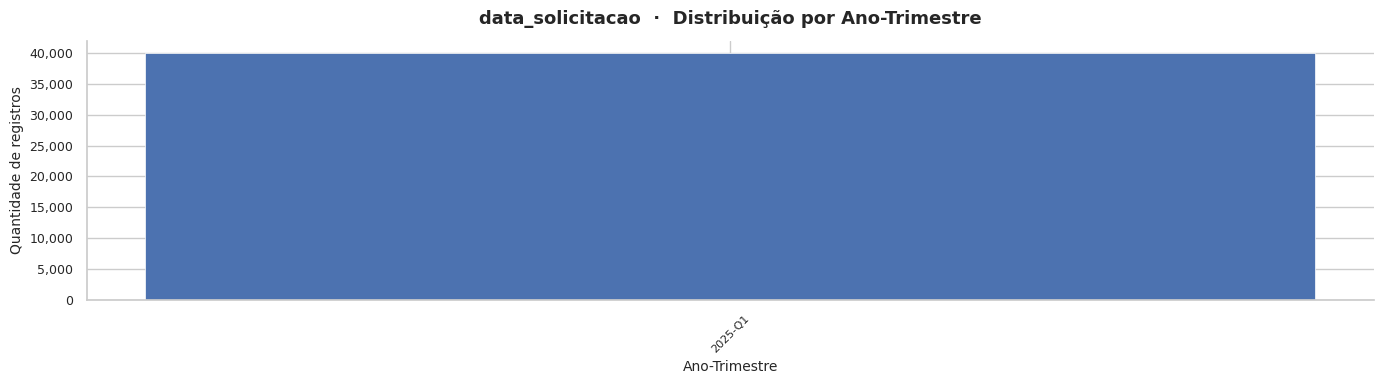

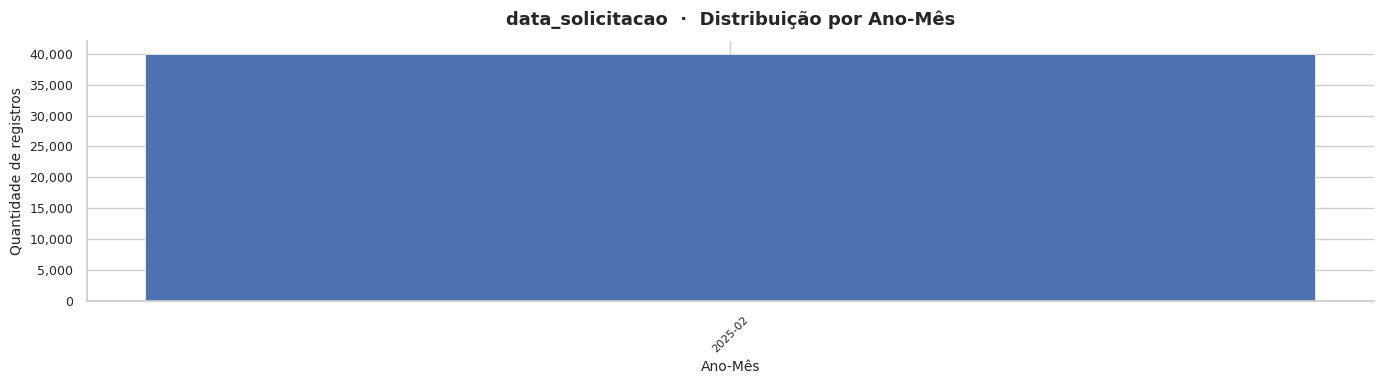

In [14]:
DataDiscovery(df_base_sub).date_analytics(['data_solicitacao'])

In [15]:
output = DataDiscovery(df_base_sub).categorical_analytics(['tipo_contrato', 'dia_semana_solicitacao'])
print(output)

Column 'tipo_contrato':
  Total Count: 40000
  Distinct Categories: 2
  Category Frequencies:
    'Cash loans': 36599 (91.50%)
    'Revolving loans': 3401 (8.50%)

Column 'dia_semana_solicitacao':
  Total Count: 40000
  Distinct Categories: 7
  Category Frequencies:
    'TUESDAY': 7231 (18.08%)
    'WEDNESDAY': 6805 (17.01%)
    'THURSDAY': 6698 (16.74%)
    'MONDAY': 6543 (16.36%)
    'FRIDAY': 6384 (15.96%)
    'SATURDAY': 4334 (10.84%)
    'SUNDAY': 2005 (5.01%)


In [16]:
output = DataDiscovery(df_base_sub).continuos_analytics(['valor_credito', 'valor_bem', 'valor_parcela'])
print(output)

Column 'valor_credito':
  Mean: 586259.6698125
  Median: 502497.0
  Std Dev: 395313.8822889432
  Min: 45000.0
  1%: 76410.0
  5%: 135000.0
  10%: 180000.0
  20%: 252531.0
  25%: 270000.0
  50%: 502497.0
  75%: 791861.625
  80%: 891072.0
  90%: 1125000.0
  95%: 1350000.0
  99%: 1812456.0
  Max: 4050000.0

Column 'valor_bem':
  Mean: 526968.1962052231
  Median: 450000.0
  Std Dev: 363020.8749499823
  Min: 40500.0
  1%: 67500.0
  5%: 135000.0
  10%: 171000.0
  20%: 225000.0
  25%: 238500.0
  50%: 450000.0
  75%: 675000.0
  80%: 765000.0
  90%: 1035000.0
  95%: 1265560.875
  99%: 1800000.0
  Max: 4050000.0

Column 'valor_parcela':
  Mean: 27376.02700270027
  Median: 25060.5
  Std Dev: 14750.171247435977
  Min: 2295.0
  1%: 6295.5
  5%: 9000.0
  10%: 11250.0
  20%: 14832.0
  25%: 16681.5
  50%: 25060.5
  75%: 34781.625
  80%: 37800.0
  90%: 46570.5
  95%: 53902.125
  99%: 71253.0
  Max: 225000.0


In [17]:
df_base_sub[['valor_credito', 'valor_bem', 'valor_parcela']].corr()

,valor_credito,valor_bem,valor_parcela
valor_credito,1.000000,0.987078,0.760548
valor_bem,0.987078,1.000000,0.766375
valor_parcela,0.760548,0.766375,1.000000


Nota-se que o valor_credito e valor_bem estão altamente correlacionado.

## Historico emprestimos

In [18]:
df_hist_emprest = pd.read_parquet('data/historico_emprestimos.parquet')

In [19]:
df_hist_emprest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186890 entries, 0 to 186889
Data columns (total 37 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id_contrato                       186890 non-null  int64  
 1   id_cliente                        186890 non-null  int64  
 2   tipo_contrato                     186890 non-null  object 
 3   status_contrato                   186890 non-null  object 
 4   data_decisao                      186890 non-null  object 
 5   data_liberacao                    7100 non-null    object 
 6   data_primeiro_vencimento          107145 non-null  object 
 7   data_ultimo_vencimento_original   101143 non-null  object 
 8   data_ultimo_vencimento            87778 non-null   object 
 9   data_encerramento                 86087 non-null   object 
 10  valor_solicitado                  186890 non-null  float64
 11  valor_credito                     186890 non-null  f

In [20]:
print(DataDiscovery(df_hist_emprest).verify_null())

Column 'data_liberacao': 179790 soft null(s) found → [None]
Column 'data_primeiro_vencimento': 79745 soft null(s) found → [None]
Column 'data_ultimo_vencimento_original': 85747 soft null(s) found → [None]
Column 'data_ultimo_vencimento': 99112 soft null(s) found → [None]
Column 'data_encerramento': 100803 soft null(s) found → [None]
Column 'valor_bem': 43437 soft null(s) found → [nan]
Column 'valor_parcela': 41764 soft null(s) found → [nan]
Column 'valor_entrada': 100168 soft null(s) found → [nan]
Column 'percentual_entrada': 100168 soft null(s) found → [nan]
Column 'qtd_parcelas_planejadas': 41763 soft null(s) found → [nan]
Column 'taxa_juros_padrao': 186262 soft null(s) found → [nan]
Column 'taxa_juros_promocional': 186262 soft null(s) found → [nan]
Column 'combinacao_produto': 32 soft null(s) found → [None]
Column 'acompanhantes_cliente': 92104 soft null(s) found → [None]
Column 'flag_seguro_contratado': 75199 soft null(s) found → [nan]


Nota-se que todos os nulos são do tipo nan


  ANÁLISE DE DATA: data_decisao
  Registros válidos : 186,890
  Período           : 2017-02-04 → 2025-02-22


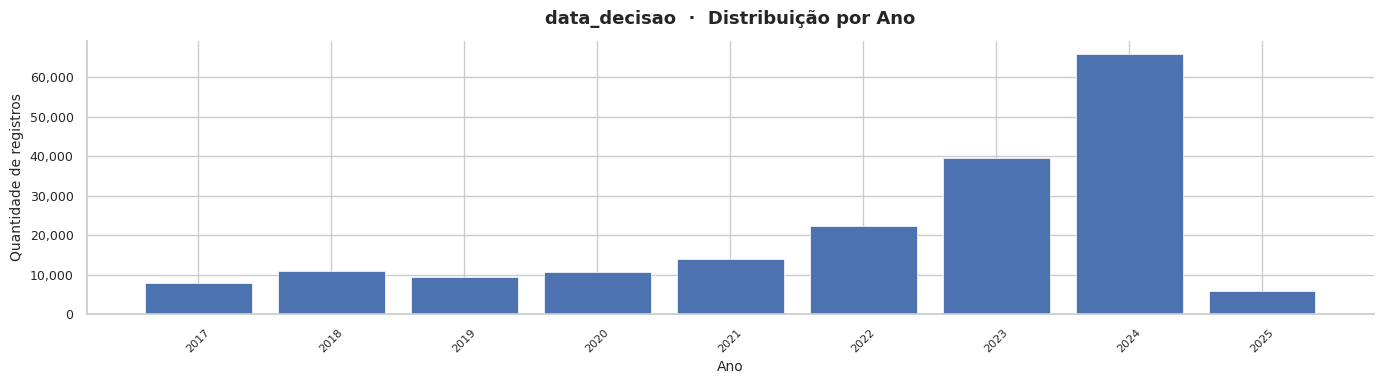

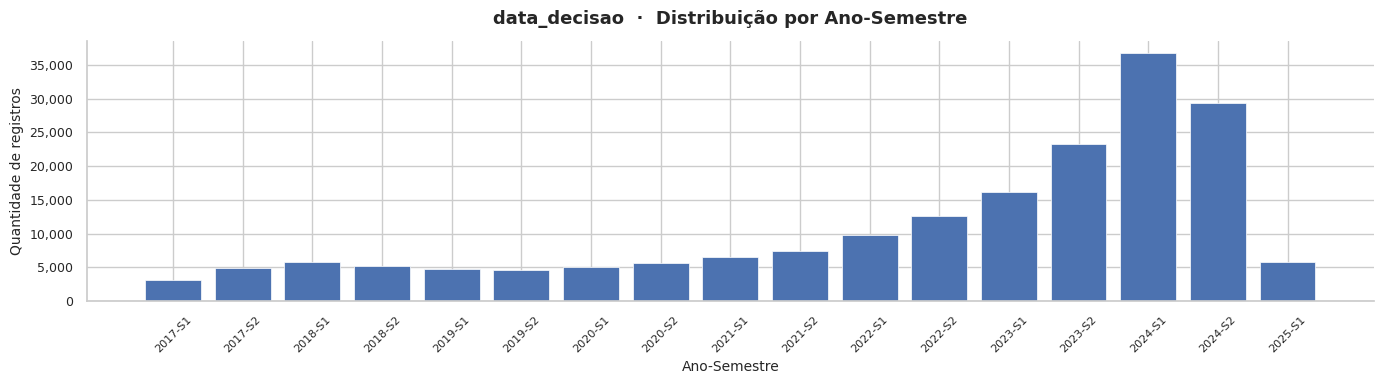

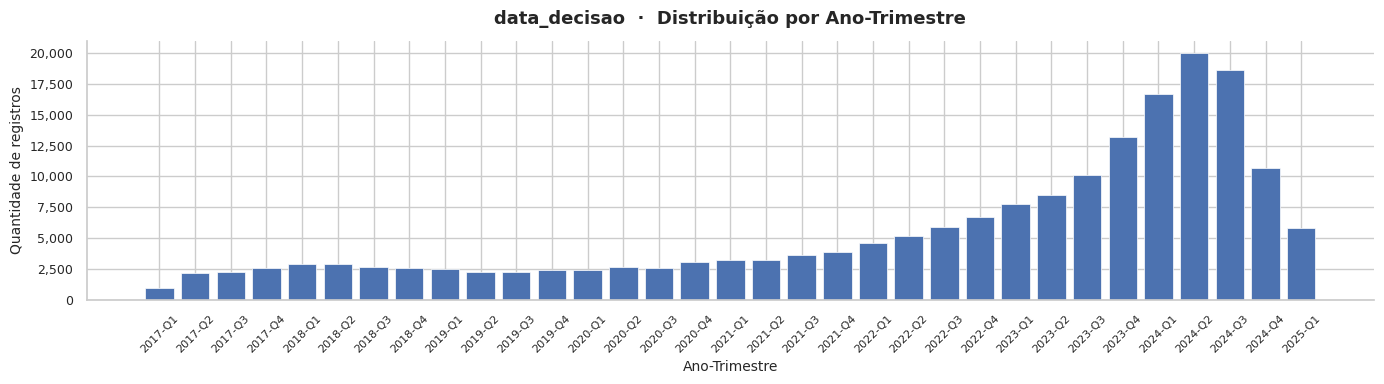

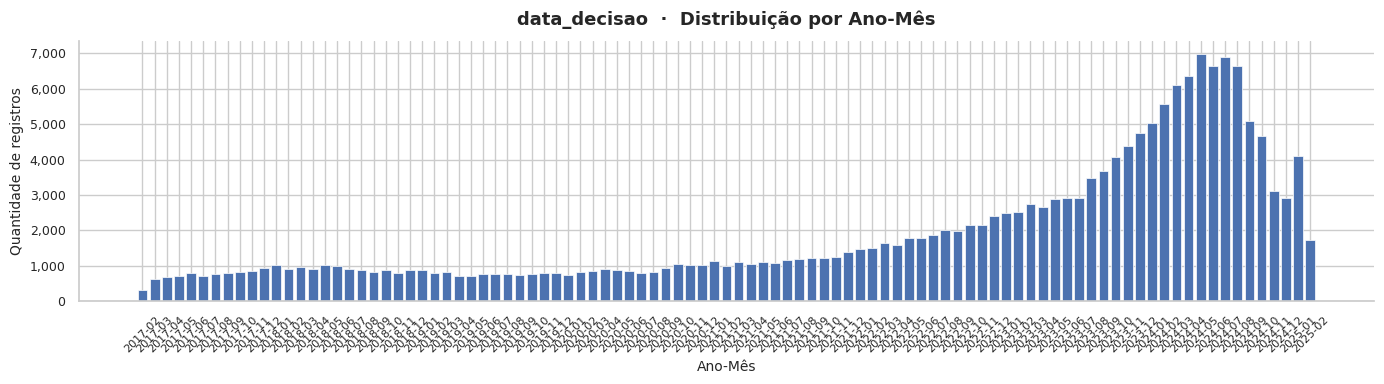

[INFO] 'data_liberacao': 179,790 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_liberacao
  Registros válidos : 7,100
  Período           : 2017-02-13 → 2025-02-21


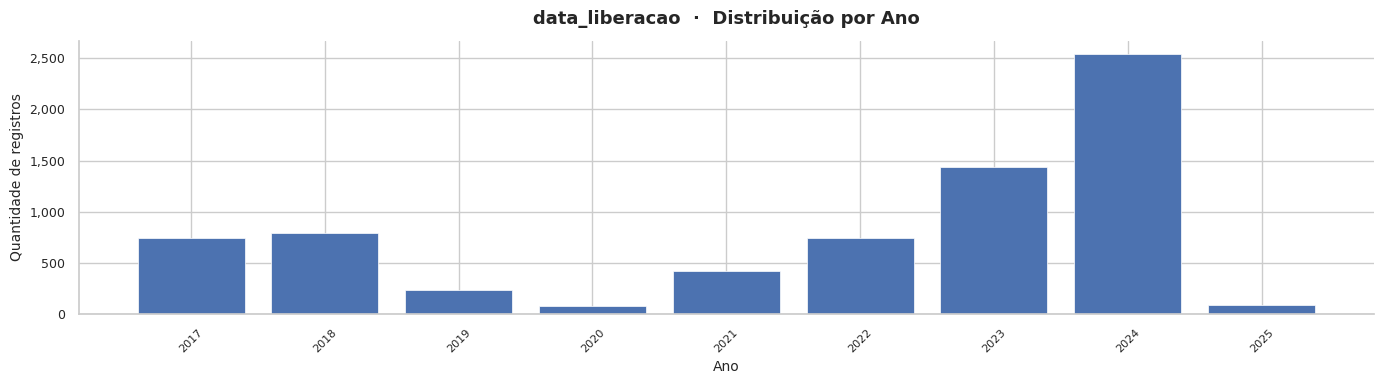

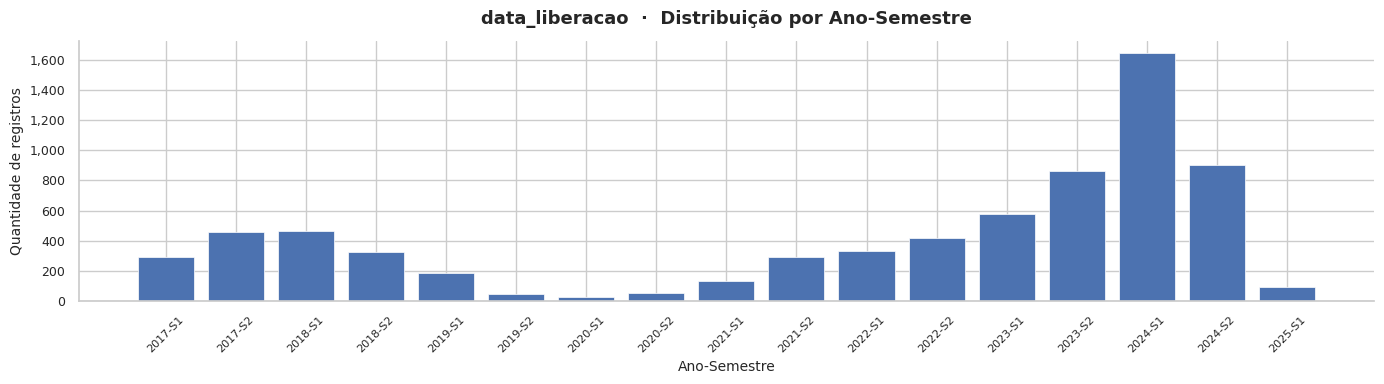

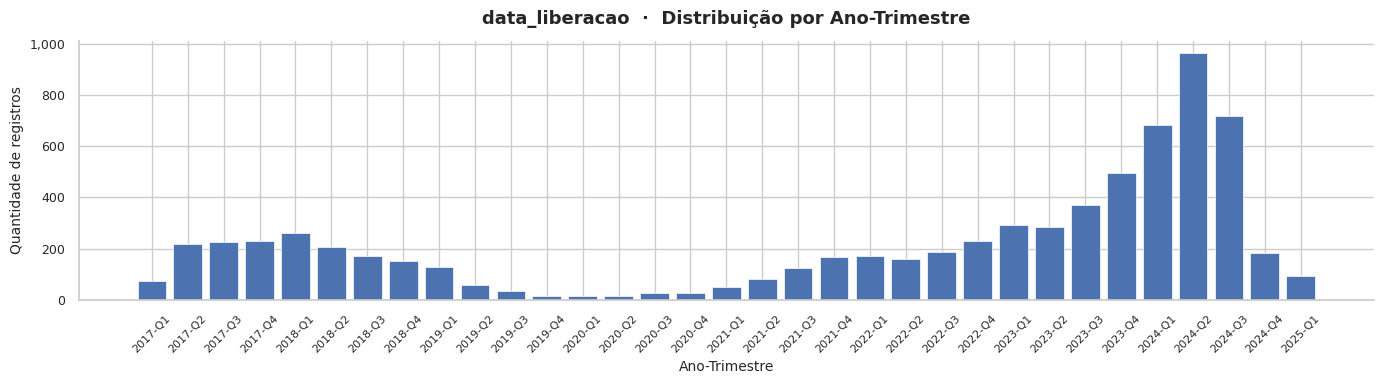

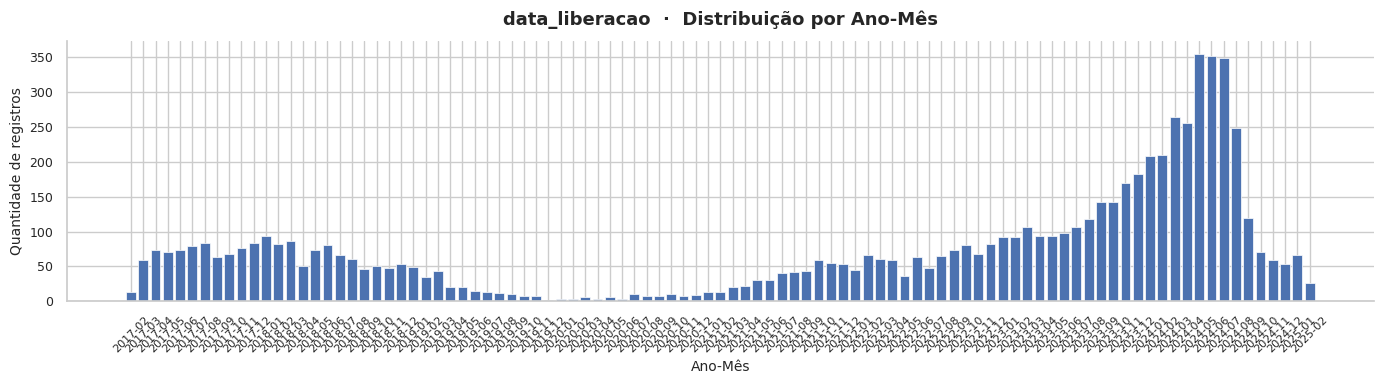

[INFO] 'data_primeiro_vencimento': 79,745 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_primeiro_vencimento
  Registros válidos : 107,145
  Período           : 2017-03-09 → 2025-02-20


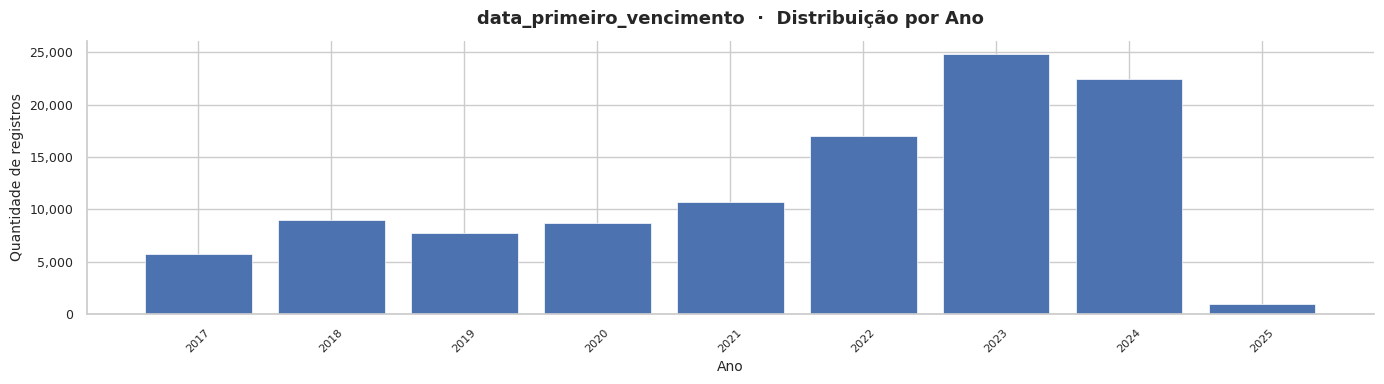

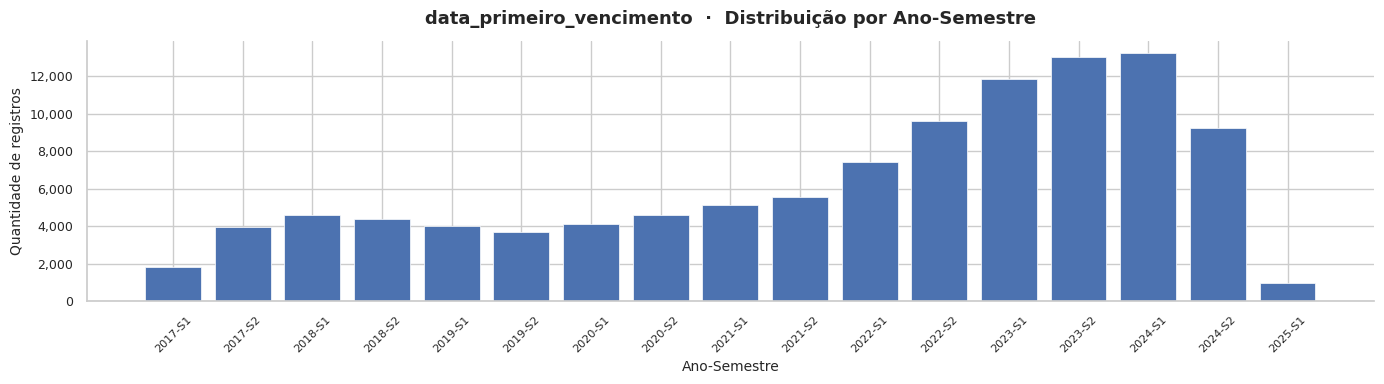

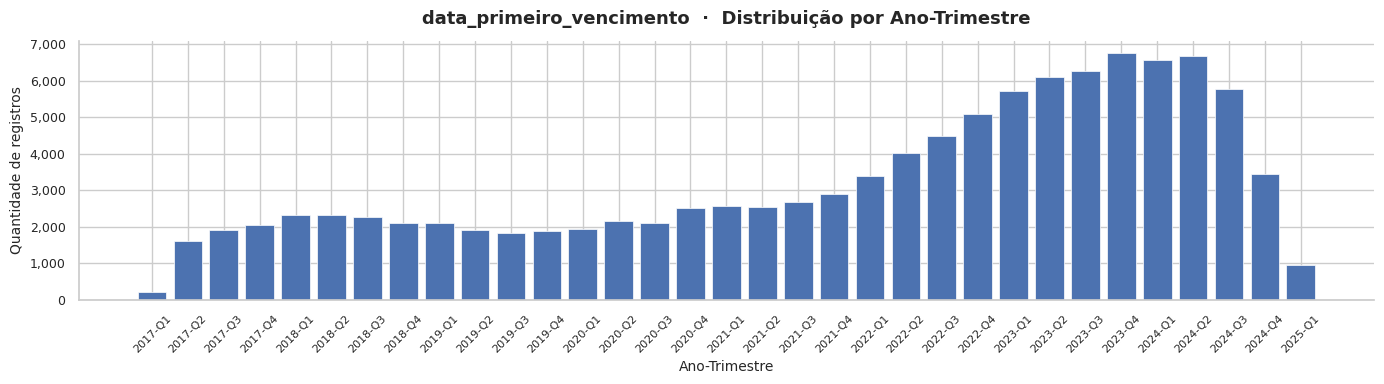

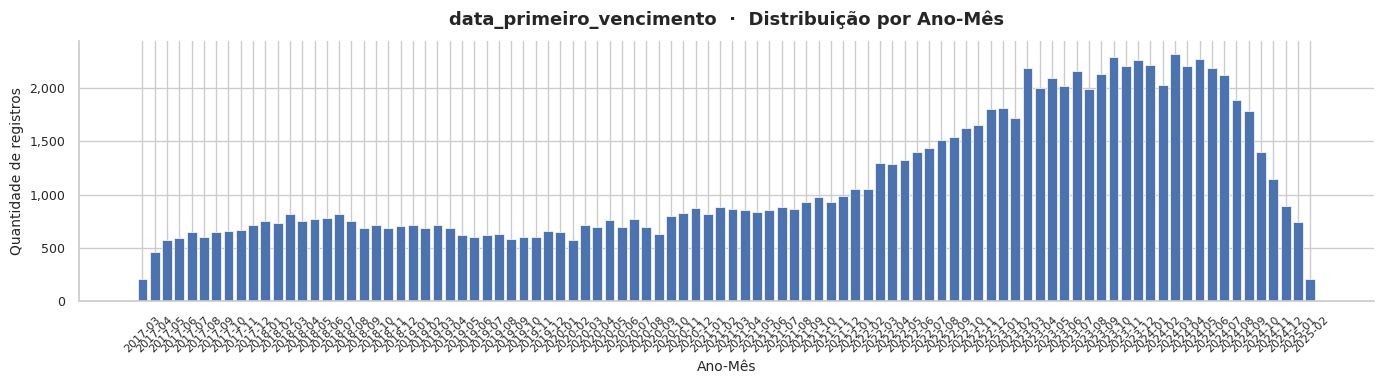

[INFO] 'data_ultimo_vencimento_original': 85,747 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_ultimo_vencimento_original
  Registros válidos : 101,143
  Período           : 2017-06-08 → 2031-08-21


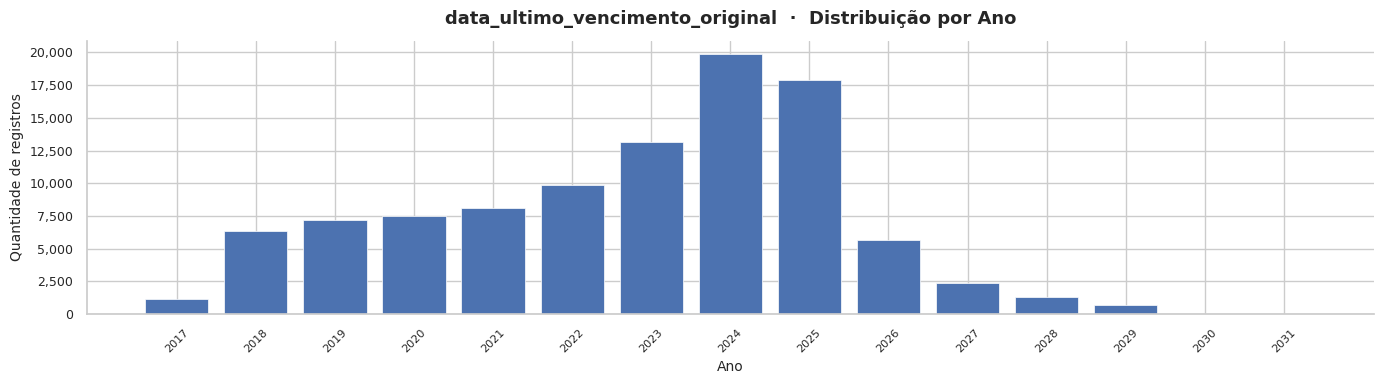

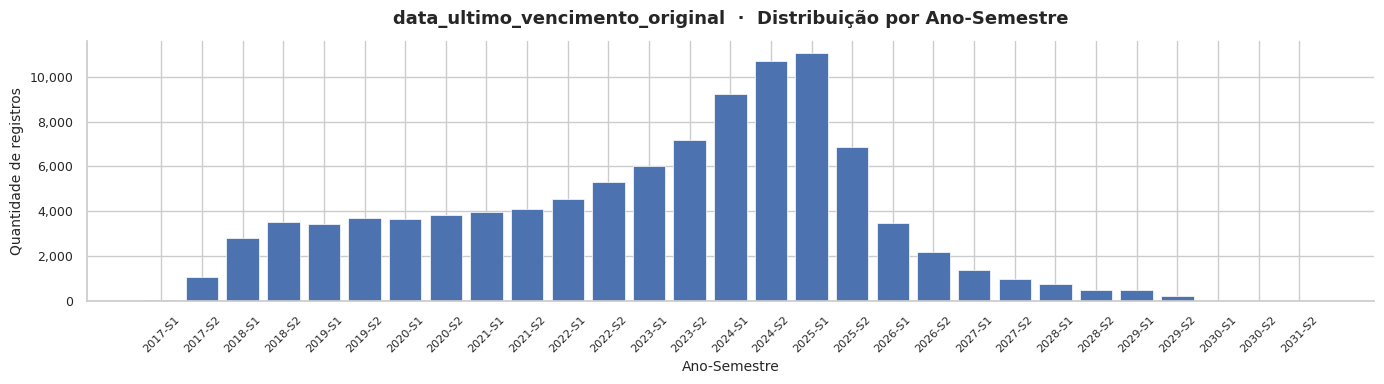

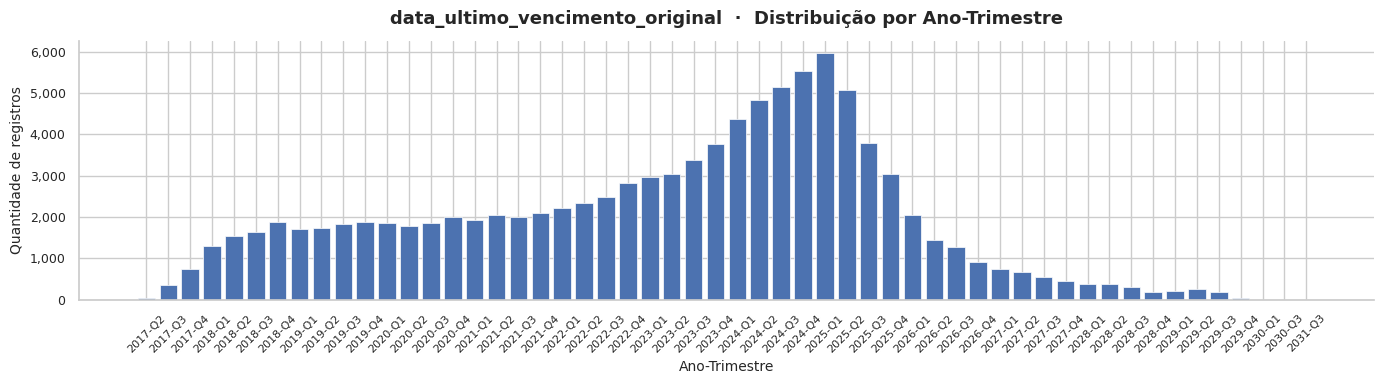

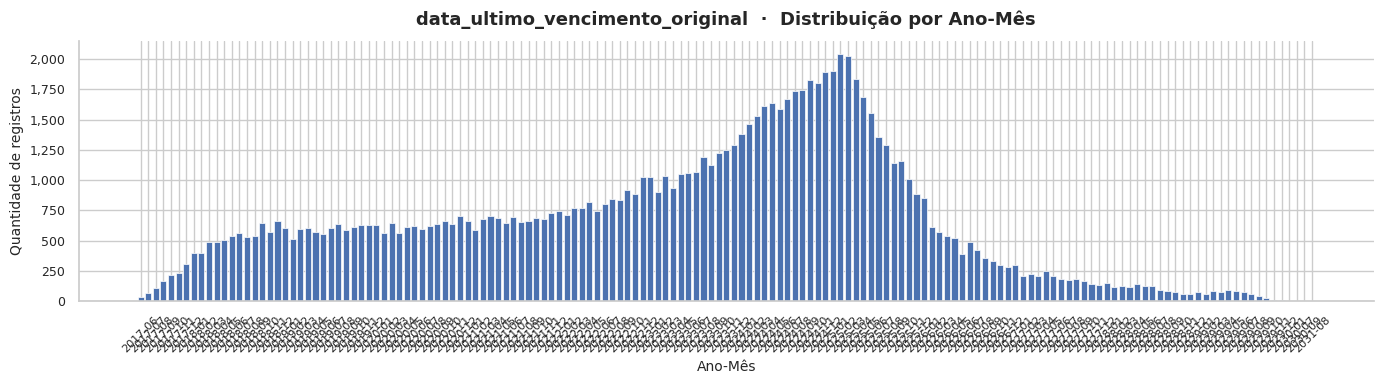

[INFO] 'data_ultimo_vencimento': 99,112 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_ultimo_vencimento
  Registros válidos : 87,778
  Período           : 2017-04-01 → 2025-02-21


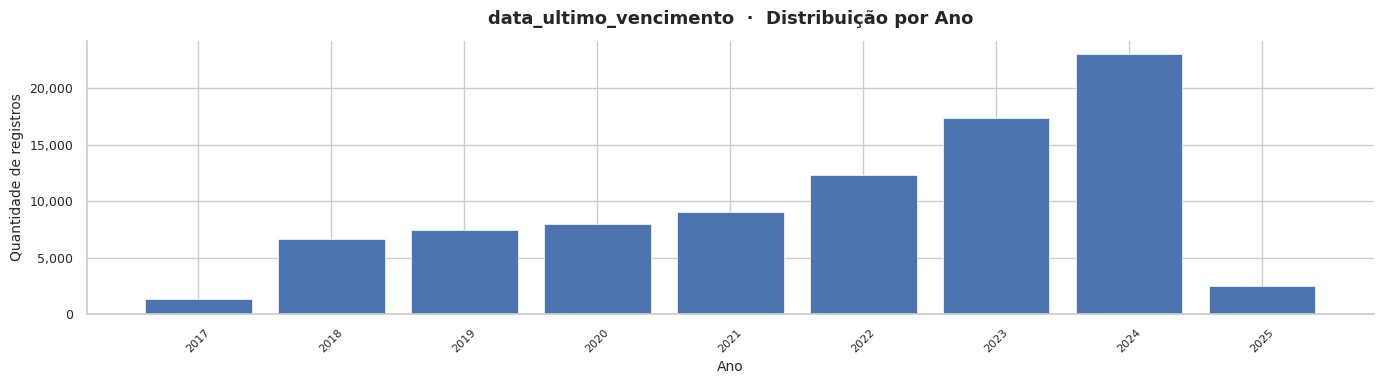

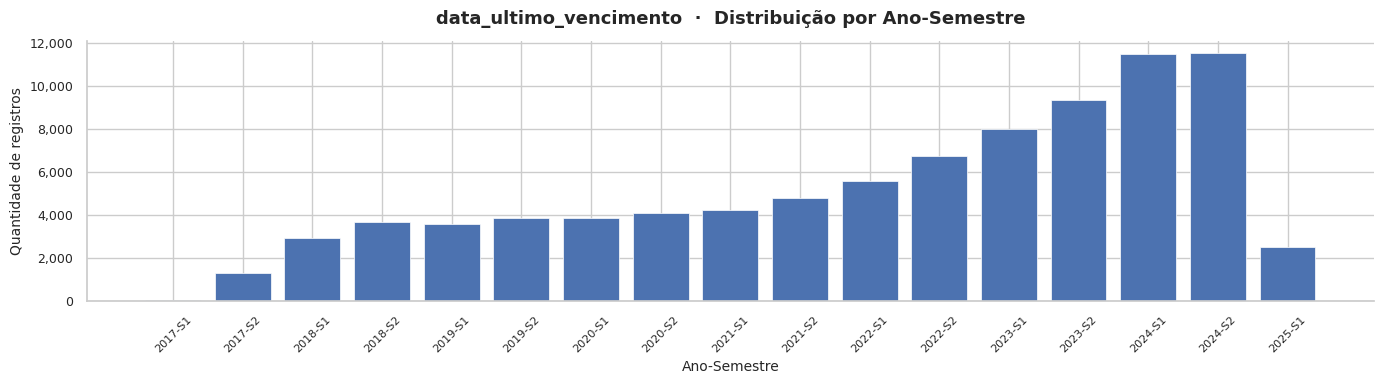

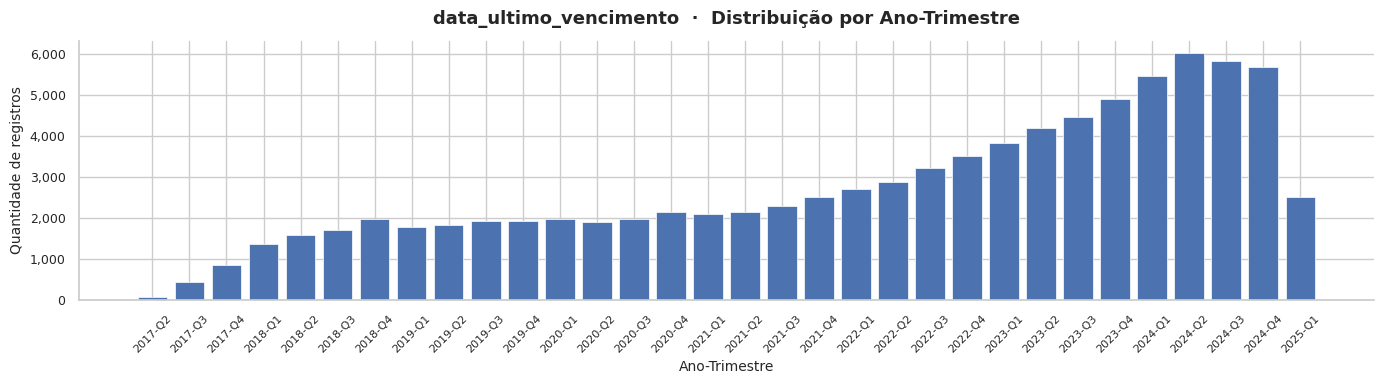

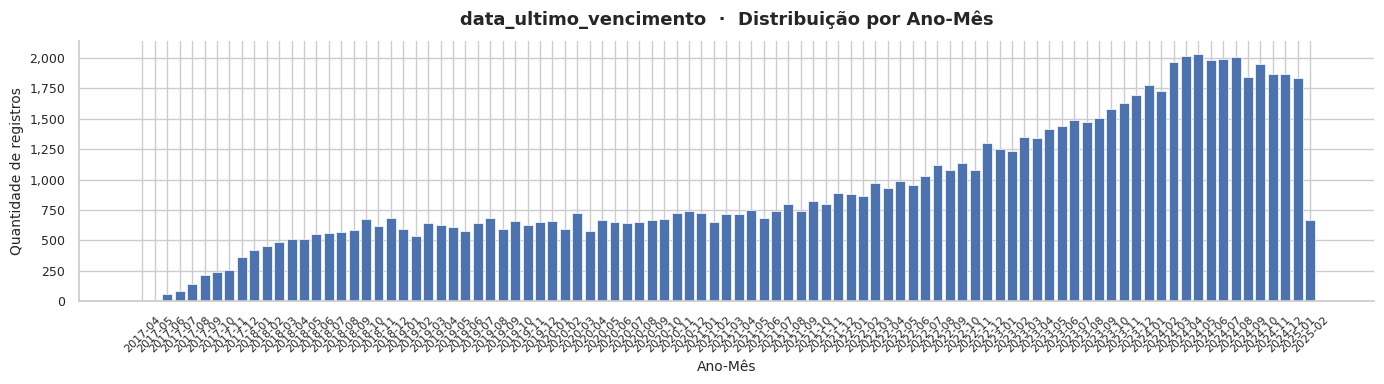

[INFO] 'data_encerramento': 100,803 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_encerramento
  Registros válidos : 86,087
  Período           : 2017-04-08 → 2025-02-22


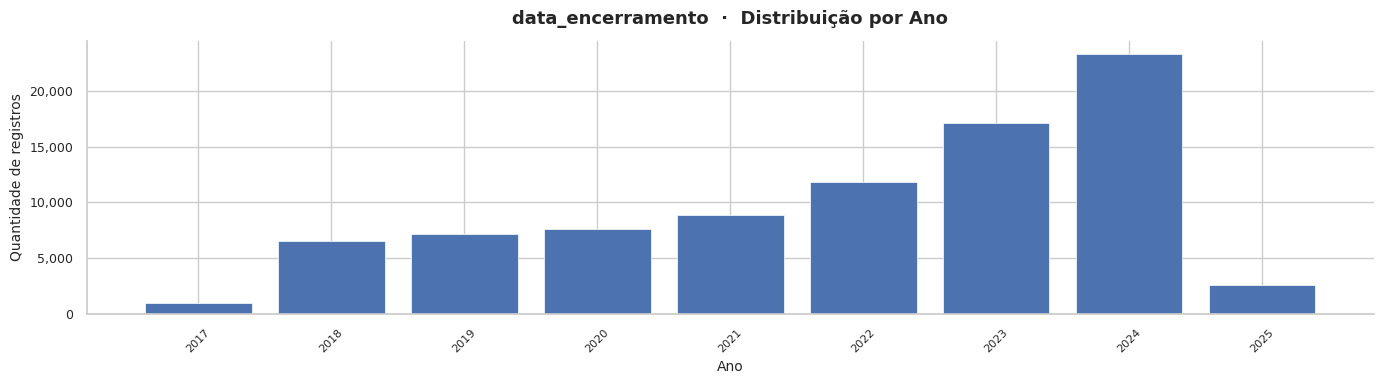

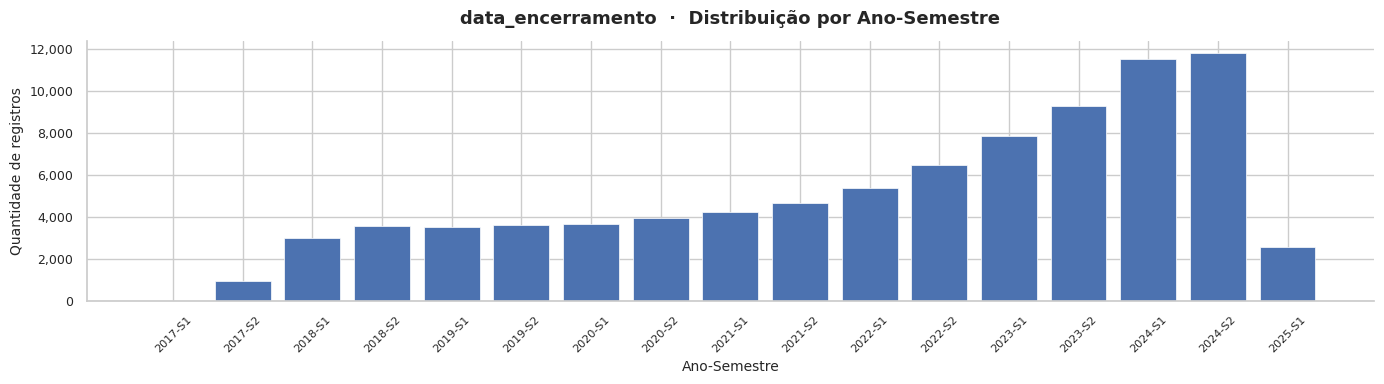

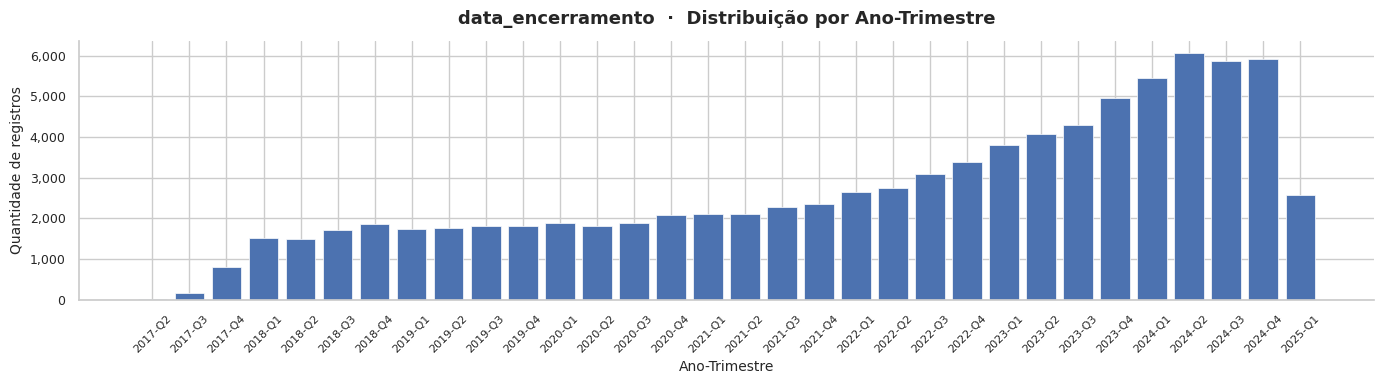

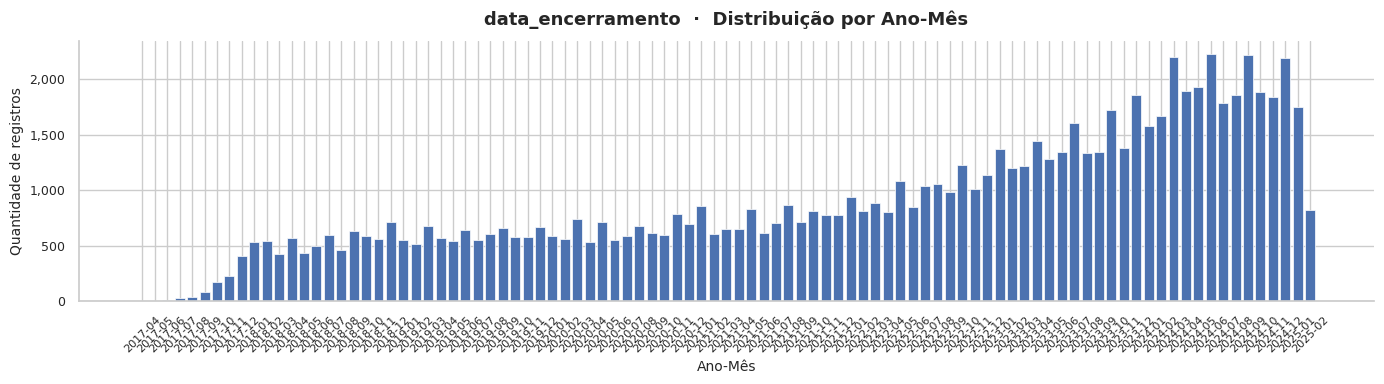

In [21]:
DataDiscovery(df_hist_emprest).date_analytics(['data_decisao', 'data_liberacao', 'data_primeiro_vencimento',
                                           'data_ultimo_vencimento_original', 'data_ultimo_vencimento',
                                           'data_encerramento'])

##### adhoc para entender melhor o motivo dessas datas estarem zeradas

vamos pegar um contrato id = 2802425

In [22]:
resultado = duckdb.sql("SELECT * FROM df_hist_emprest where id_contrato=2802425").df()
resultado

,id_contrato,id_cliente,tipo_contrato,status_contrato,data_decisao,data_liberacao,data_primeiro_vencimento,data_ultimo_vencimento_original,data_ultimo_vencimento,data_encerramento,...,setor_vendedor,canal_venda,area_venda,dia_semana_solicitacao,hora_solicitacao,flag_ultima_solicitacao_contrato,flag_ultima_solicitacao_dia,motivo_recusa,acompanhantes_cliente,flag_seguro_contratado
0,2802425,108129,Cash loans,Approved,2024-08-29,None,2024-09-28,2027-08-14,None,None,...,XNA,Contact center,-1,THURSDAY,11,Y,1,XAP,Unaccompanied,1.0


vamos refazer novamente a analise acima, agora apenas com status approved


  ANÁLISE DE DATA: data_decisao
  Registros válidos : 116,182
  Período           : 2017-02-04 → 2025-02-22


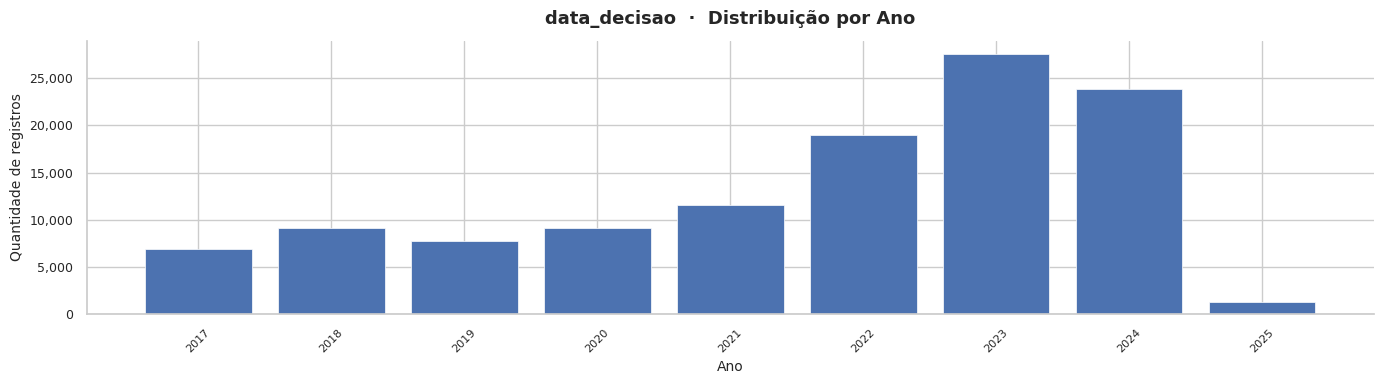

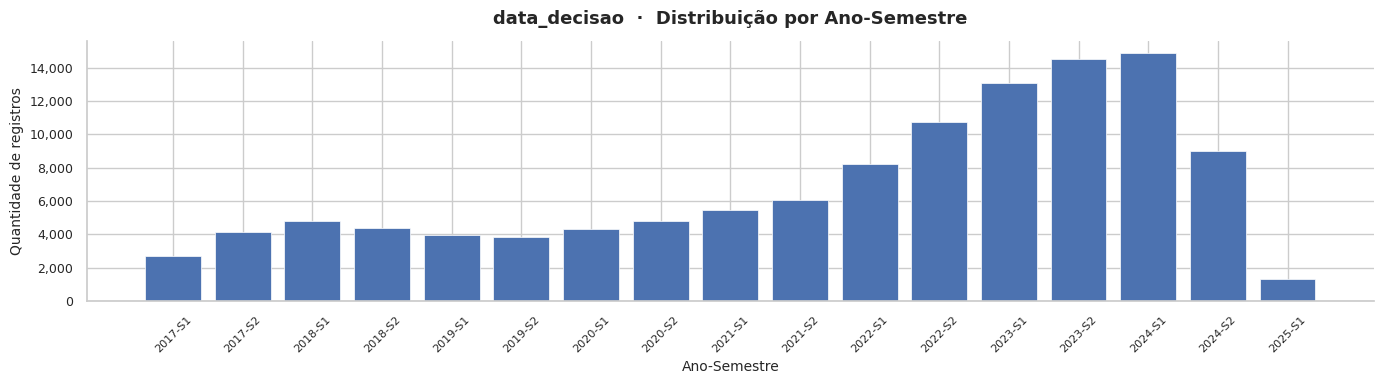

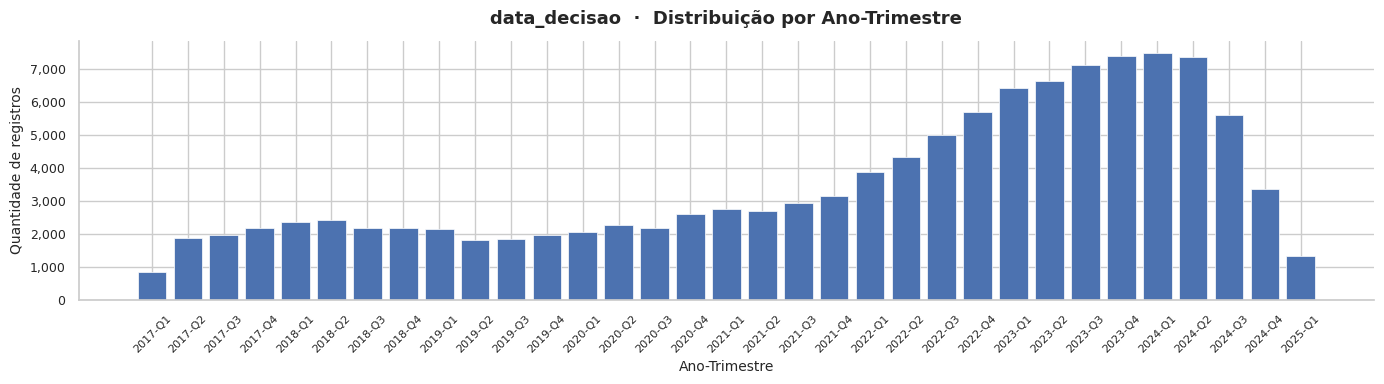

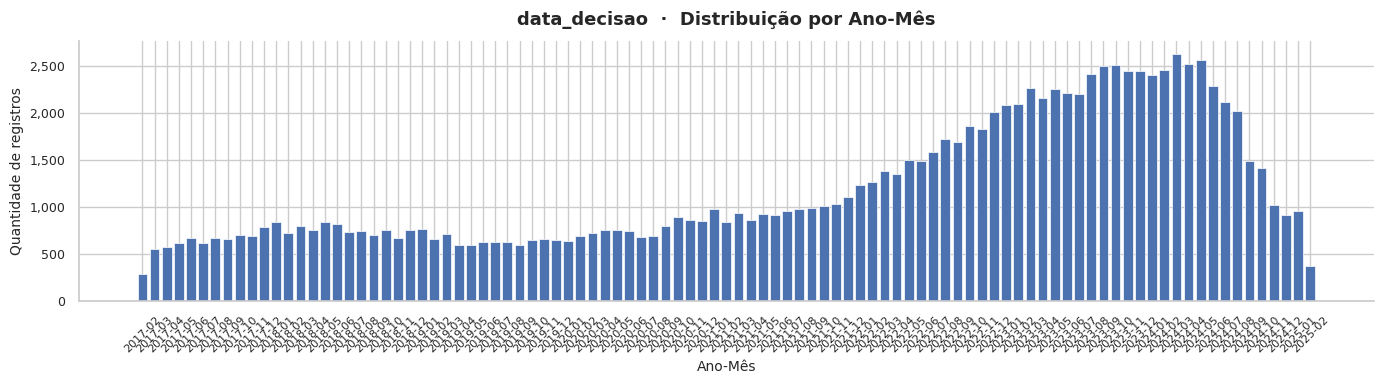

[INFO] 'data_liberacao': 109,082 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_liberacao
  Registros válidos : 7,100
  Período           : 2017-02-13 → 2025-02-21


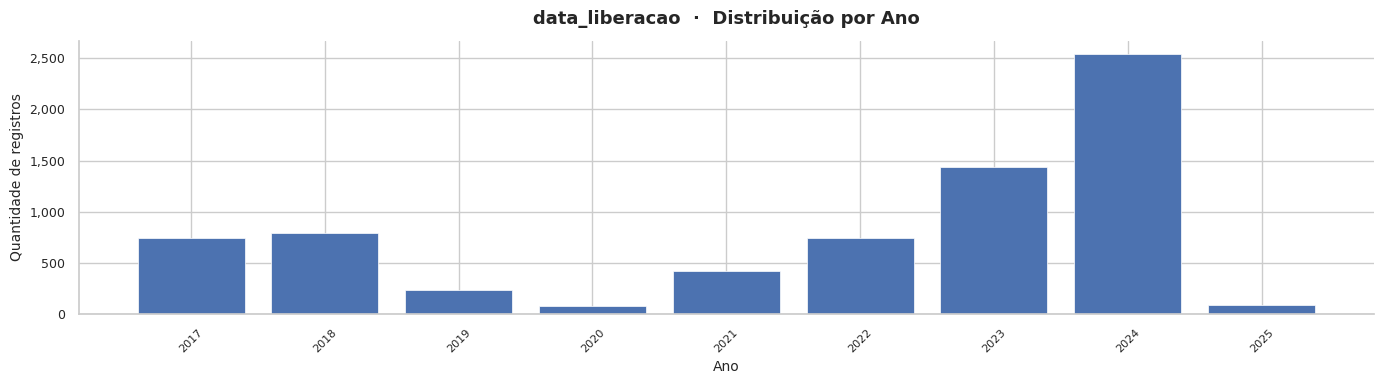

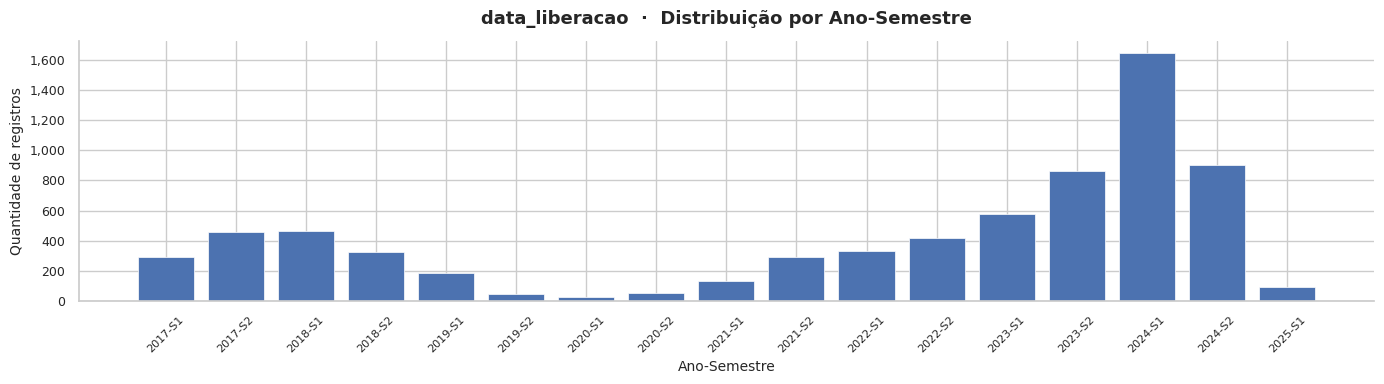

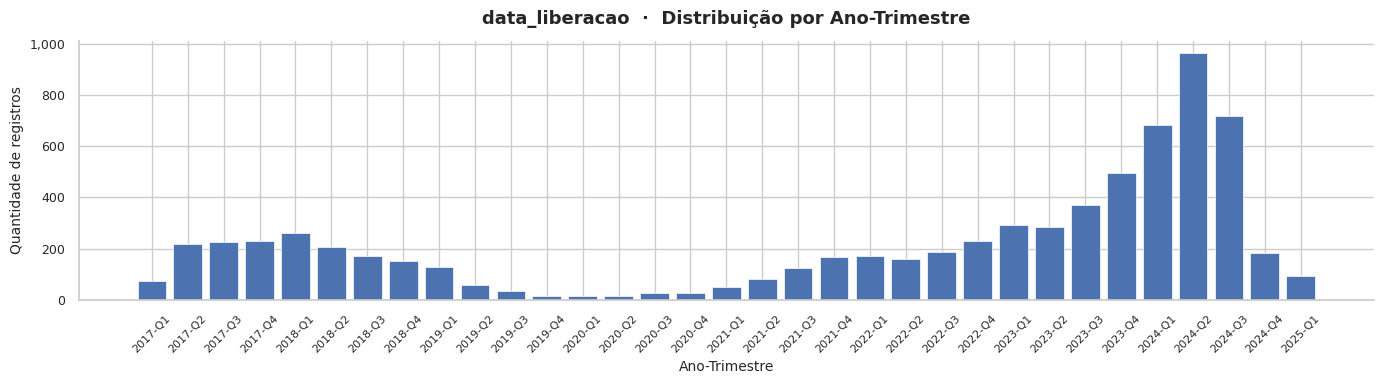

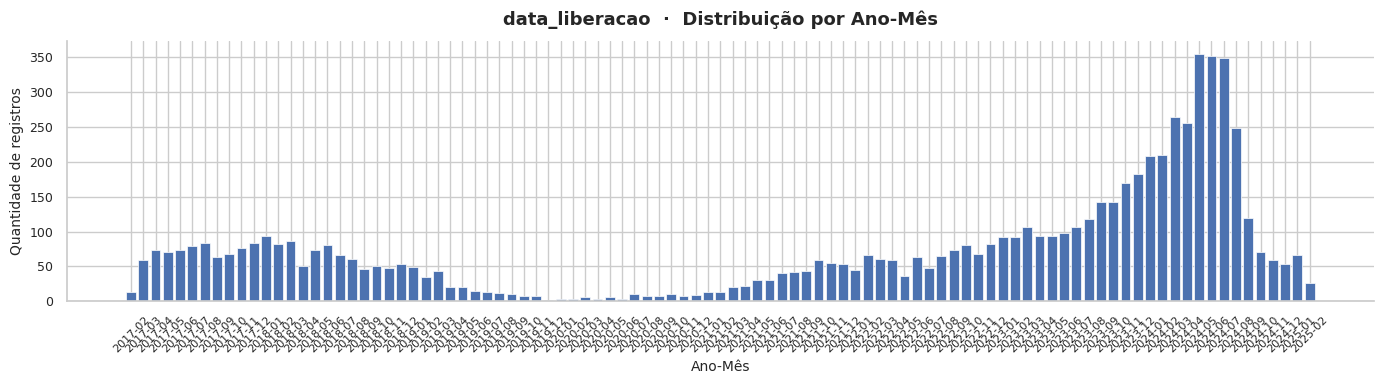

[INFO] 'data_primeiro_vencimento': 9,037 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_primeiro_vencimento
  Registros válidos : 107,145
  Período           : 2017-03-09 → 2025-02-20


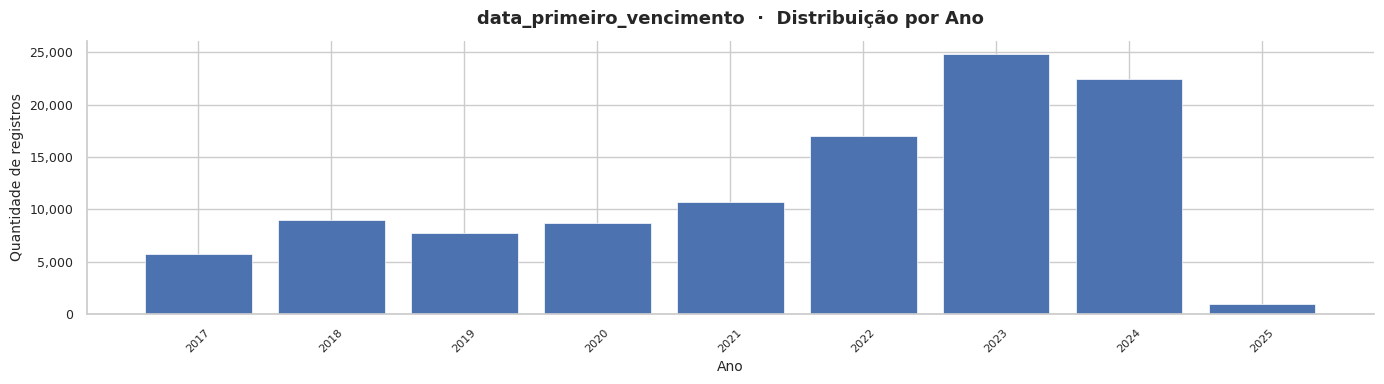

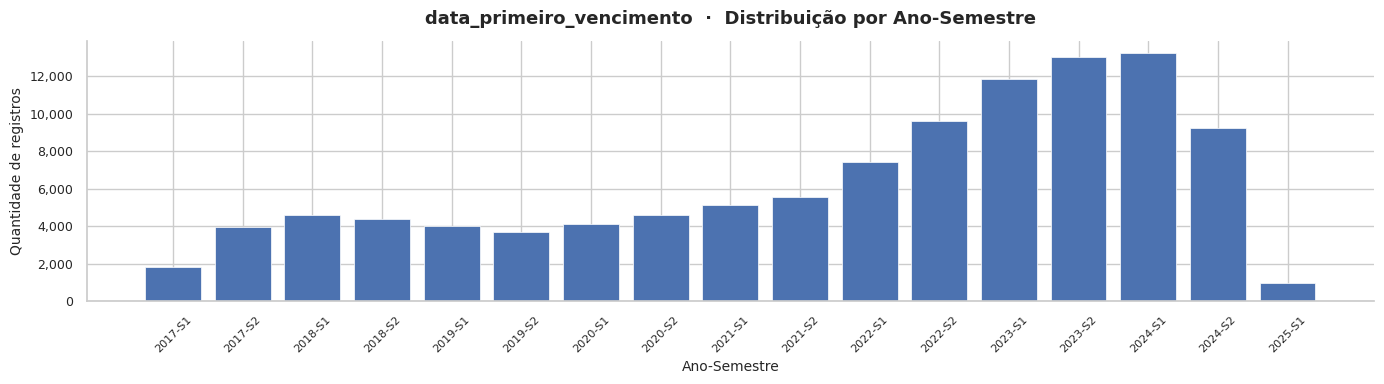

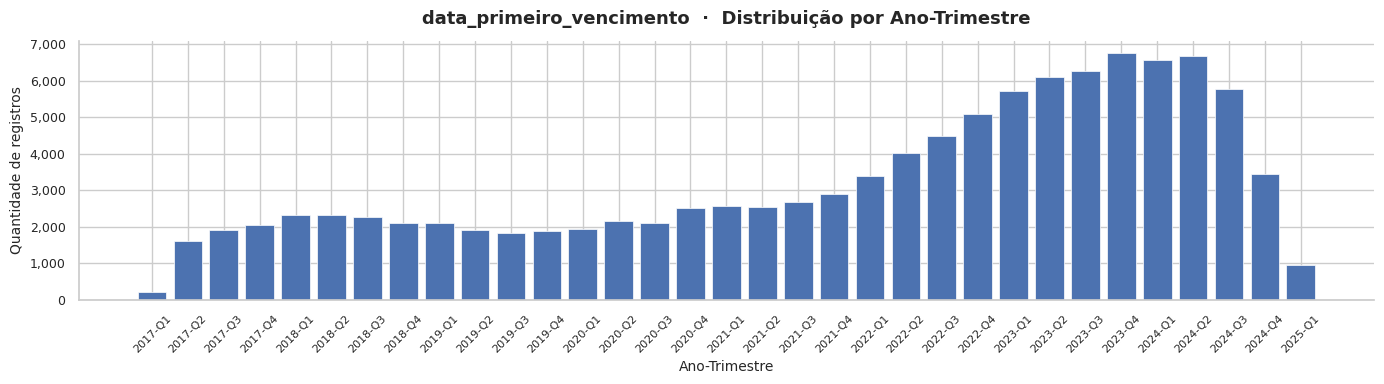

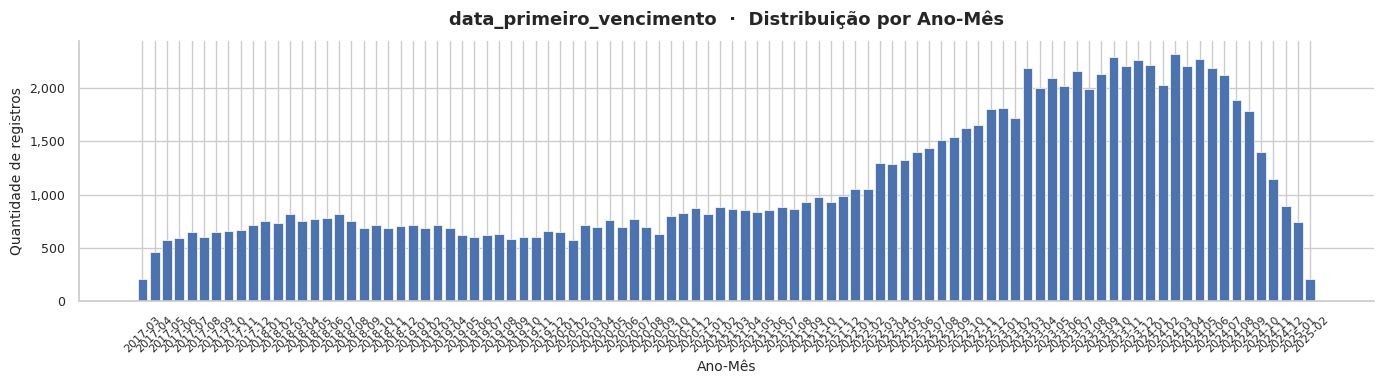

[INFO] 'data_ultimo_vencimento_original': 15,039 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_ultimo_vencimento_original
  Registros válidos : 101,143
  Período           : 2017-06-08 → 2031-08-21


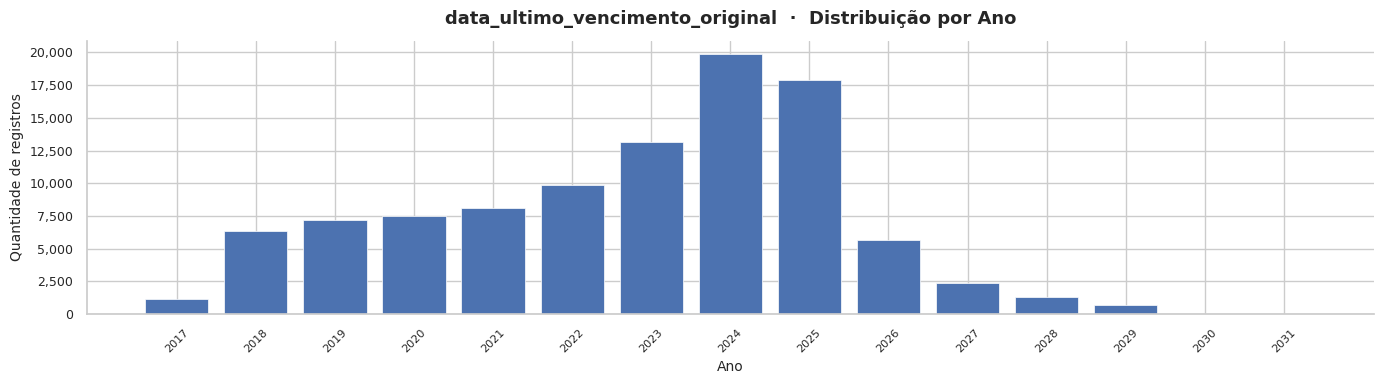

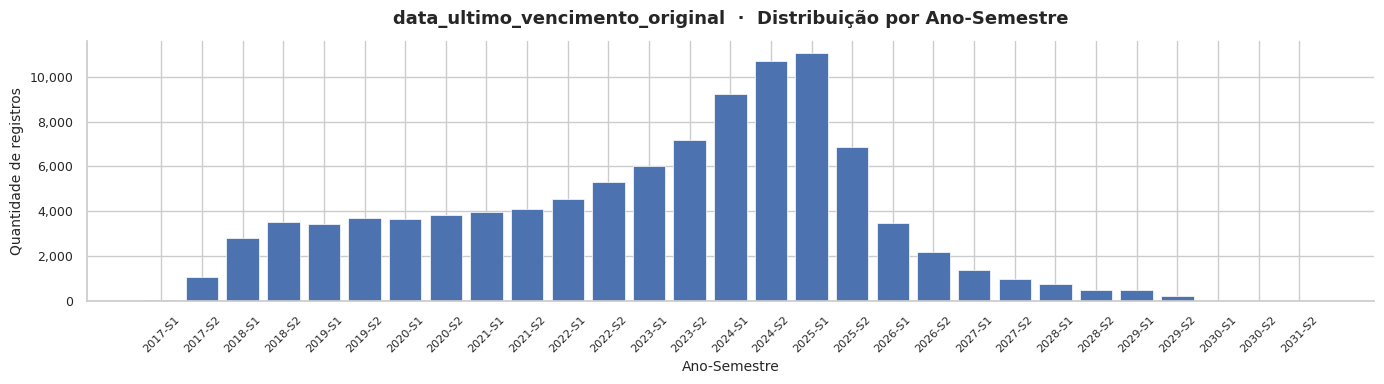

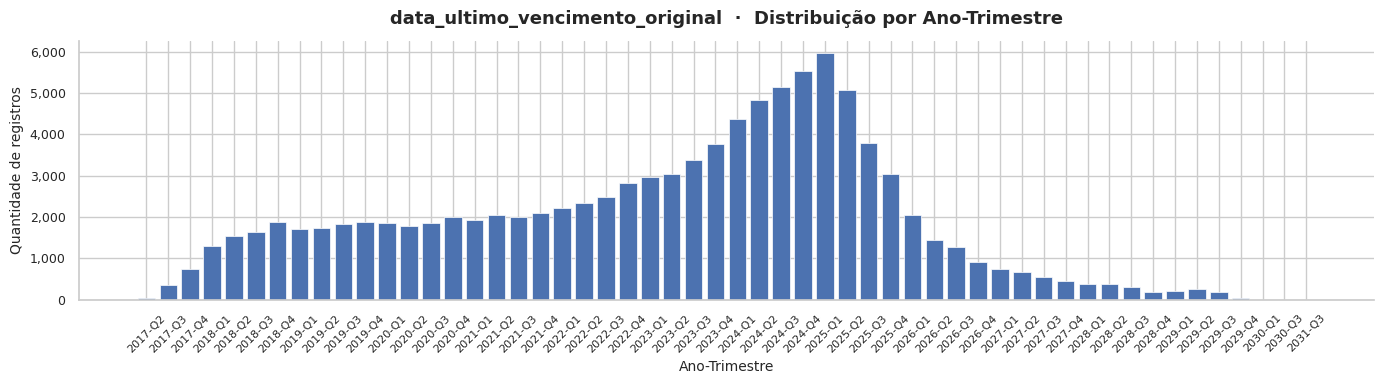

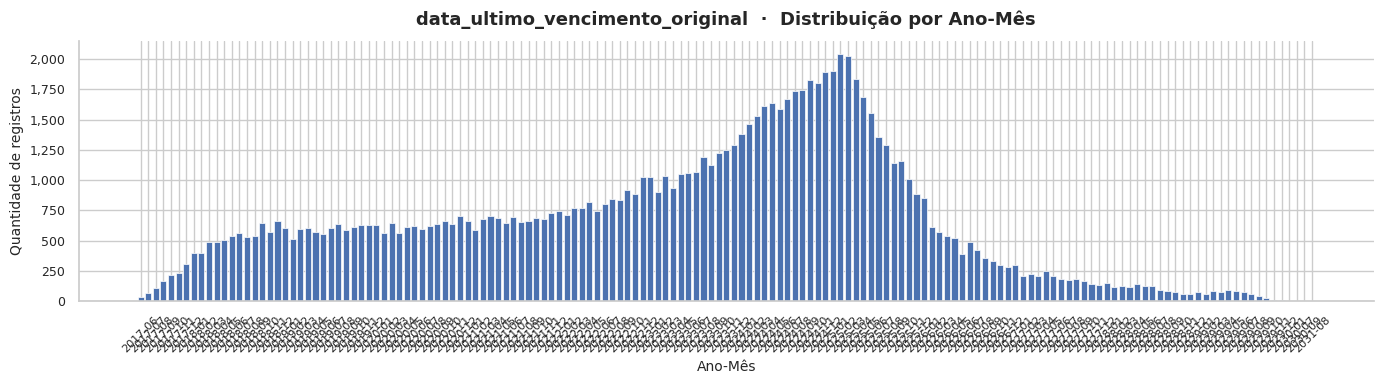

[INFO] 'data_ultimo_vencimento': 28,404 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_ultimo_vencimento
  Registros válidos : 87,778
  Período           : 2017-04-01 → 2025-02-21


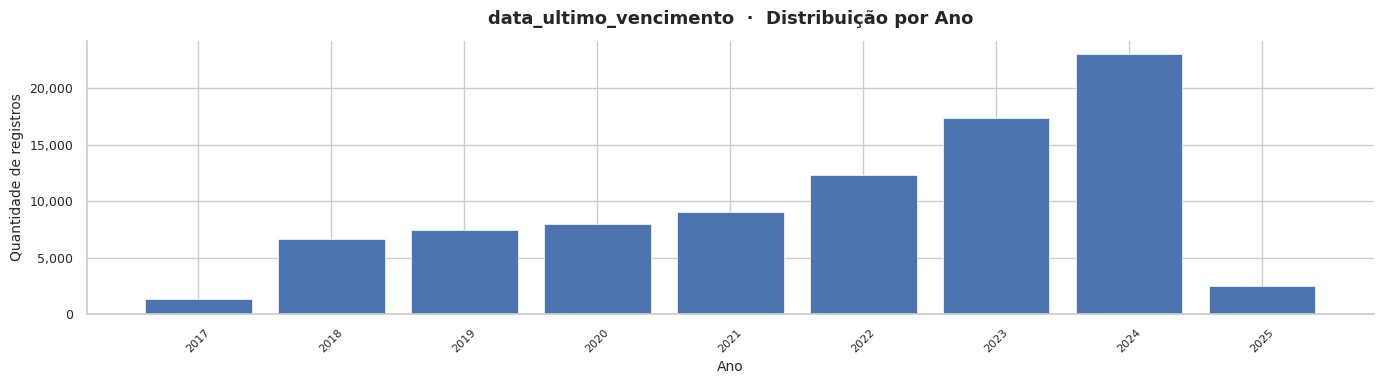

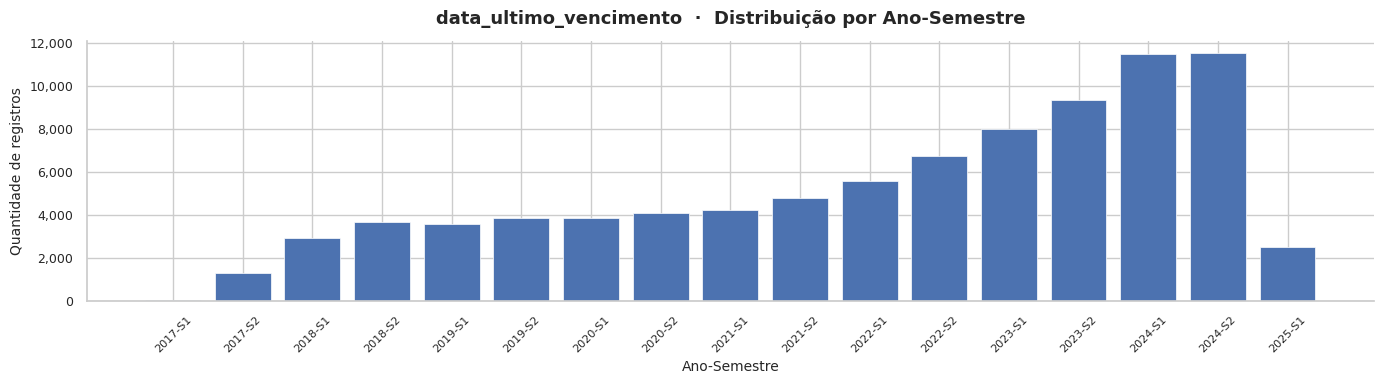

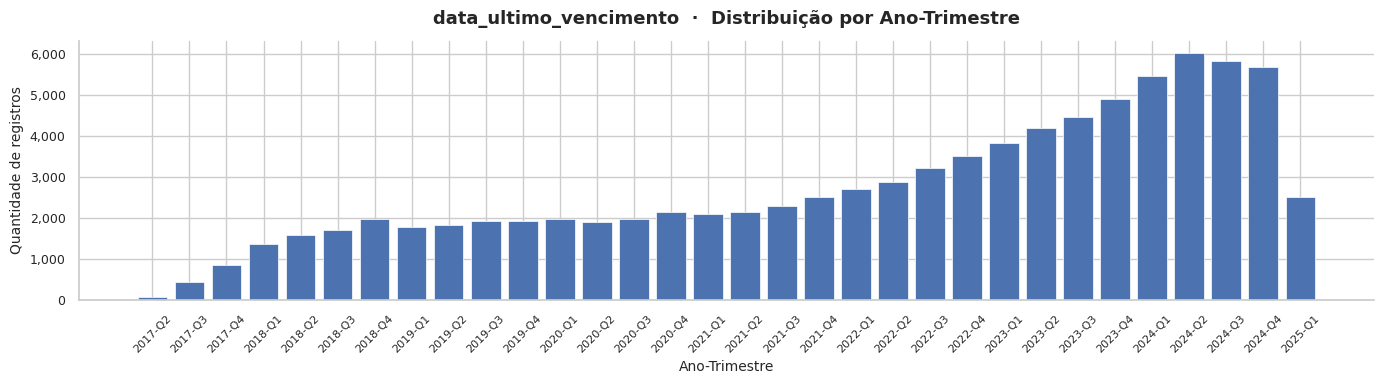

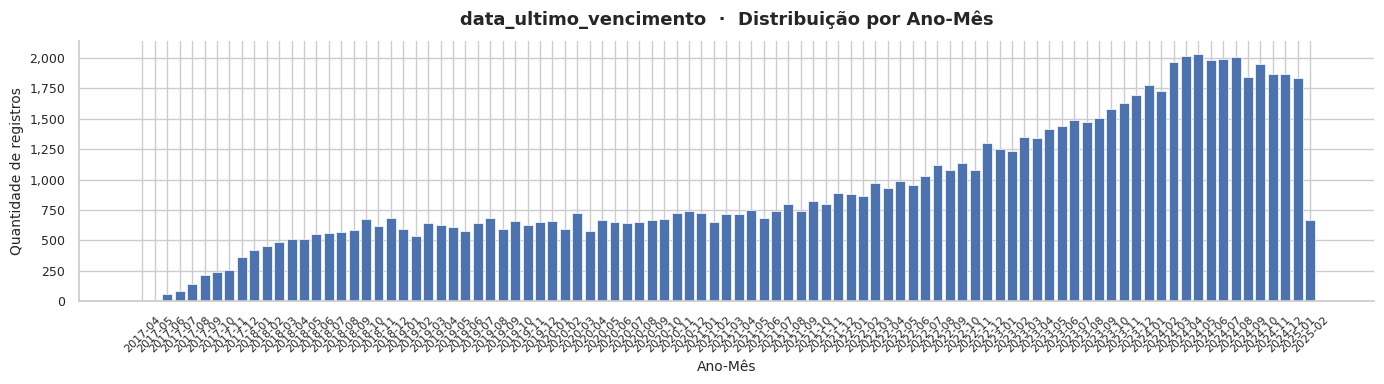

[INFO] 'data_encerramento': 30,095 valores nulos ignorados nas agregações.

  ANÁLISE DE DATA: data_encerramento
  Registros válidos : 86,087
  Período           : 2017-04-08 → 2025-02-22


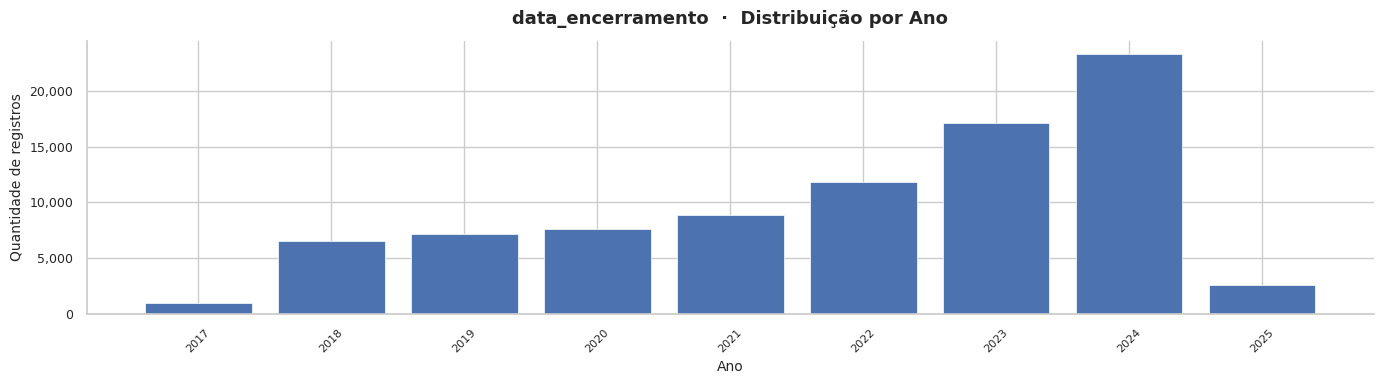

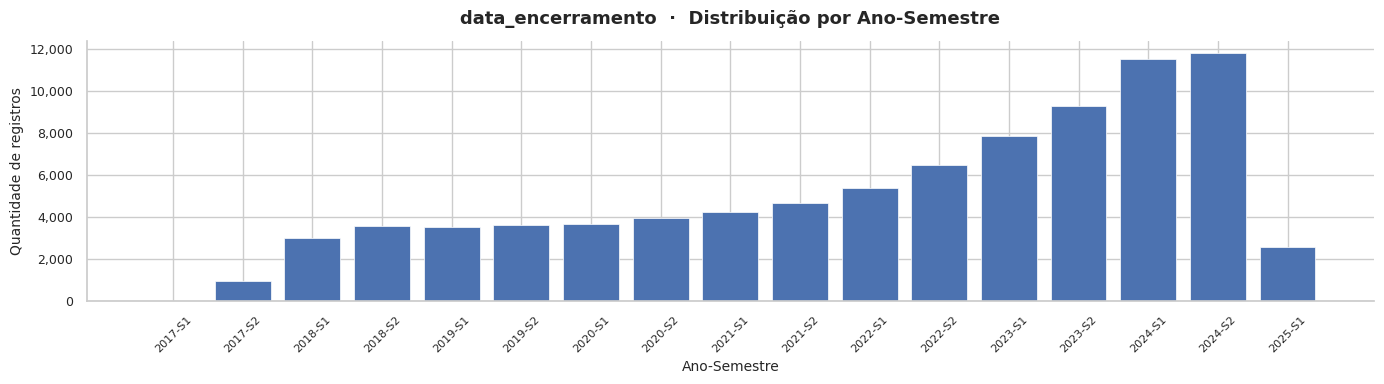

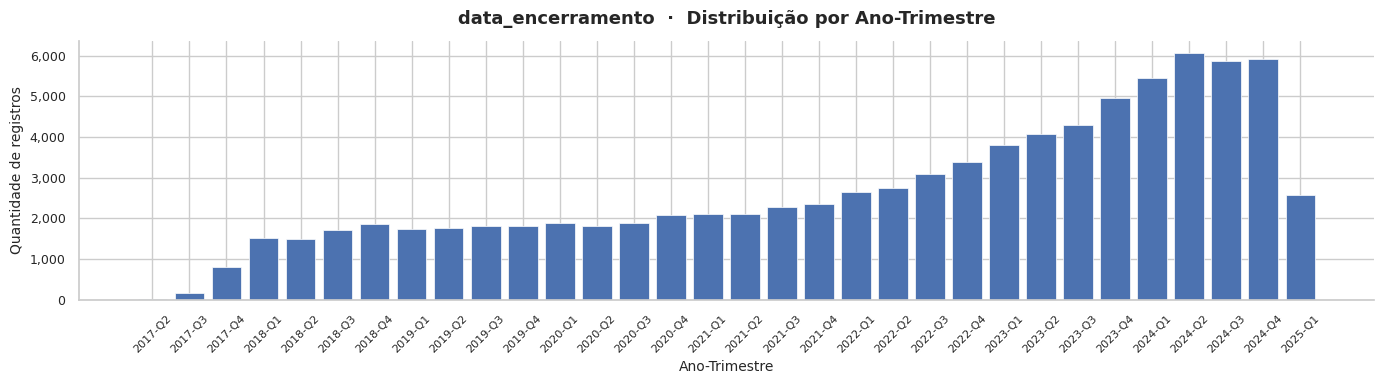

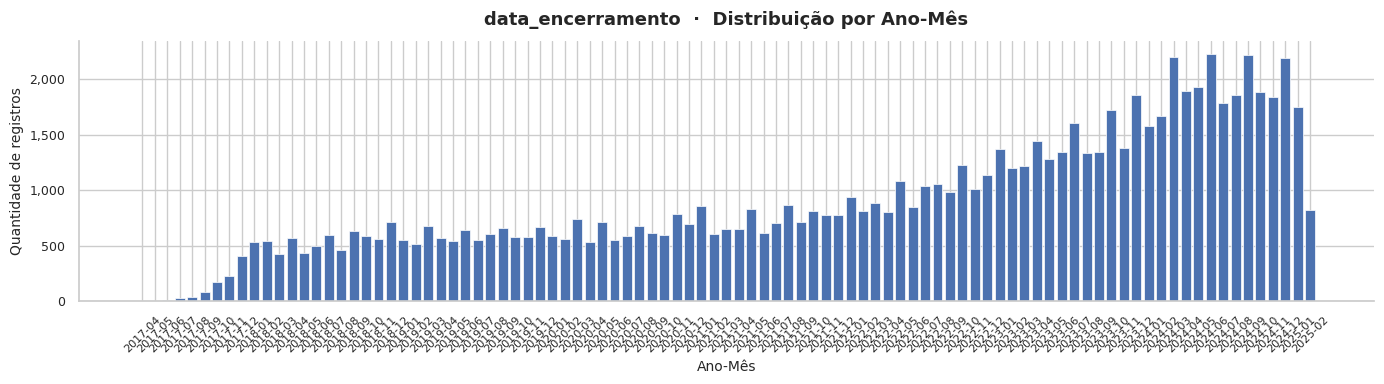

In [23]:
DataDiscovery(df_hist_emprest[df_hist_emprest['status_contrato'] == 'Approved']).date_analytics(['data_decisao', 'data_liberacao',
                                                                                                'data_primeiro_vencimento',
                                                                                                'data_ultimo_vencimento_original',
                                                                                                'data_ultimo_vencimento','data_encerramento'])

por que existem contratos sem data_vencimento? 

In [24]:
pd.set_option('display.max_columns', None)
resultado = duckdb.sql("SELECT * FROM df_hist_emprest where data_ultimo_vencimento is null").df()
resultado 

,id_contrato,id_cliente,tipo_contrato,status_contrato,data_decisao,data_liberacao,data_primeiro_vencimento,data_ultimo_vencimento_original,data_ultimo_vencimento,data_encerramento,valor_solicitado,valor_credito,valor_bem,valor_parcela,valor_entrada,percentual_entrada,qtd_parcelas_planejadas,taxa_juros_padrao,taxa_juros_promocional,tipo_pagamento,finalidade_emprestimo,tipo_cliente,faixa_rendimento,tipo_portfolio,tipo_produto,categoria_bem,combinacao_produto,setor_vendedor,canal_venda,area_venda,dia_semana_solicitacao,hora_solicitacao,flag_ultima_solicitacao_contrato,flag_ultima_solicitacao_dia,motivo_recusa,acompanhantes_cliente,flag_seguro_contratado
0,2802425,108129,Cash loans,Approved,2024-08-29,None,2024-09-28,2027-08-14,None,None,607500.0,679671.0,607500.0,25188.615,NaN,NaN,36.0,NaN,NaN,XNA,XNA,Repeater,low_action,Cash,x-sell,XNA,Cash X-Sell: low,XNA,Contact center,-1,THURSDAY,11,Y,1,XAP,Unaccompanied,1.0
1,1182516,267782,Cash loans,Approved,2023-04-08,None,2023-05-08,2025-09-24,None,None,405000.0,451777.5,405000.0,20361.600,NaN,NaN,30.0,NaN,NaN,Cash through the bank,XNA,Repeater,low_normal,Cash,x-sell,XNA,Cash X-Sell: low,XNA,Credit and cash offices,-1,SATURDAY,4,Y,1,XAP,None,1.0
2,2261993,299391,Revolving loans,Canceled,2024-09-06,None,None,None,None,None,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XNA,XAP,Repeater,XNA,XNA,XNA,XNA,Card Street,XNA,Credit and cash offices,-1,FRIDAY,13,Y,1,XAP,None,NaN
3,2586409,446260,Cash loans,Canceled,2024-07-18,None,None,None,None,None,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XNA,XNA,Repeater,XNA,XNA,XNA,XNA,Cash,XNA,Credit and cash offices,-1,THURSDAY,16,Y,1,XAP,None,NaN
4,1385097,369423,Consumer loans,Approved,2020-12-11,None,None,None,None,None,19611.0,14170.5,19611.0,2652.705,6111.0,0.328153,6.0,NaN,NaN,Cash through the bank,XAP,Repeater,middle,POS,XNA,Audio/Video,POS household with interest,Consumer electronics,Country-wide,2078,FRIDAY,12,Y,1,XAP,"Spouse, partner",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99107,1637460,110314,Cash loans,Canceled,2024-05-05,None,None,None,None,None,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XNA,XNA,Refreshed,XNA,XNA,XNA,XNA,Cash,XNA,Contact center,-1,SUNDAY,17,Y,1,XAP,None,NaN
99108,2175955,378430,Cash loans,Canceled,2025-01-08,None,None,None,None,None,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XNA,XNA,Repeater,XNA,XNA,XNA,XNA,Cash,XNA,Contact center,-1,WEDNESDAY,11,Y,1,XAP,None,NaN
99109,1304099,172575,Cash loans,Canceled,2024-11-20,None,None,None,None,None,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XNA,XNA,Repeater,XNA,XNA,XNA,XNA,Cash,XNA,Contact center,-1,WEDNESDAY,11,Y,1,XAP,None,NaN
99110,2381880,175920,Cash loans,Canceled,2024-06-07,None,None,None,None,None,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XNA,XNA,Repeater,XNA,XNA,XNA,XNA,Cash,XNA,Contact center,-1,FRIDAY,11,Y,1,XAP,None,NaN


##### variaveis categoricas

In [25]:
output = DataDiscovery(df_hist_emprest).categorical_analytics(['tipo_contrato', 'status_contrato',
                                                              'tipo_pagamento', 'finalidade_emprestimo',
                                                               'tipo_cliente', 'faixa_rendimento',
                                                                'tipo_portfolio', 'tipo_produto',
                                                               'categoria_bem', 'combinacao_produto',
                                                                'setor_vendedor', 'canal_venda'])
print(output)

Column 'tipo_contrato':
  Total Count: 186890
  Distinct Categories: 4
  Category Frequencies:
    'Cash loans': 83546 (44.70%)
    'Consumer loans': 81684 (43.71%)
    'Revolving loans': 21628 (11.57%)
    'XNA': 32 (0.02%)

Column 'status_contrato':
  Total Count: 186890
  Distinct Categories: 4
  Category Frequencies:
    'Approved': 116182 (62.17%)
    'Canceled': 35767 (19.14%)
    'Refused': 32108 (17.18%)
    'Unused offer': 2833 (1.52%)

Column 'tipo_pagamento':
  Total Count: 186890
  Distinct Categories: 4
  Category Frequencies:
    'Cash through the bank': 115570 (61.84%)
    'XNA': 70250 (37.59%)
    'Non-cash from your account': 914 (0.49%)
    'Cashless from the account of the employer': 156 (0.08%)

Column 'finalidade_emprestimo':
  Total Count: 186890
  Distinct Categories: 25
  Category Frequencies:
    'XAP': 103344 (55.30%)
    'XNA': 75821 (40.57%)
    'Repairs': 2605 (1.39%)
    'Other': 1662 (0.89%)
    'Urgent needs': 964 (0.52%)
    'Buying a used car': 340 (0.

Observa-se que algumas variáveis categóricas apresentam bom potencial preditivo para o modelo de inadimplência, enquanto outras exigem tratamento mais cuidadoso devido à alta concentração de valores ausentes ou genéricos (como *XNA*).

A variável **tipo_contrato** mostra-se bastante relevante, pois possui distribuição equilibrada entre categorias e forte relação esperada com o risco de crédito. De forma semelhante, **tipo_portfolio** também apresenta boa diversidade e pode capturar diferenças importantes entre produtos financeiros.

A variável **tipo_pagamento** tem potencial informativo, porém apresenta uma proporção significativa de valores *XNA*. Ainda assim, pode ser útil ao ser transformada em variáveis dummy, especialmente se o padrão de ausência carregar sinal (o que é comum em dados de crédito).

Já **tipo_cliente** é promissora, pois diferencia perfis comportamentais (cliente novo vs recorrente), o que costuma ter impacto direto na inadimplência.

Por outro lado, **faixa_rendimento** apresenta uma alta concentração de valores *XNA*, o que pode limitar seu poder preditivo. Nesse caso, é recomendável avaliar se a ausência de informação em si já representa um sinal relevante antes de decidir pela exclusão.

A variável **tipo_produto** também requer análise adicional. Apesar da predominância de *XNA*, pode ser útil dependendo de como esses valores se distribuem em relação ao target.

**combinacao_produto** se destaca como uma variável com alto potencial preditivo, pois incorpora múltiplas dimensões (tipo de produto, canal e perfil). No entanto, exige um pré-processamento mais elaborado, como agrupamento de categorias ou encoding mais sofisticado, devido à sua granularidade.

Por fim, **canal_venda** também é uma variável relevante, já que diferentes canais costumam estar associados a perfis distintos de risco.

---

### Resumo

- Variáveis com maior potencial:
  - `tipo_contrato`
  - `tipo_portfolio`
  - `tipo_cliente`
  - `combinacao_produto`
  - `canal_venda`

- Variáveis que exigem cautela (alto volume de *XNA*):
  - `tipo_pagamento`
  - `faixa_rendimento`
  - `tipo_produto`

Em síntese, variáveis com alta presença de valores ausentes não devem ser descartadas automaticamente, pois a ausência pode carregar informação relevante para o modelo.

# parcelas

In [26]:
df_hist_parcelas = pd.read_parquet('data/historico_parcelas.parquet')

In [27]:
df_hist_parcelas

,id_contrato,id_cliente,versao_parcela,numero_parcela,data_prevista_pagamento,data_real_pagamento,valor_previsto_parcela,valor_pago_parcela
0,1594684,100193,0.0,56,2021-12-21,2021-12-21,301.86,301.860
1,1995642,134723,1.0,38,2021-08-09,2021-08-04,12949.20,12949.200
2,1720935,176364,1.0,9,2024-03-06,2024-03-04,61192.53,61192.530
3,1439208,154898,1.0,20,2024-08-11,2024-08-07,8851.23,8851.230
4,1640082,172575,1.0,4,2022-11-15,2022-11-10,8720.28,8720.280
...,...,...,...,...,...,...,...,...
1390973,2372059,405754,0.0,2,2024-07-12,2024-07-12,35370.00,35370.000
1390974,2452681,454098,2.0,7,2022-08-24,2022-08-20,53710.02,53710.020
1390975,1635645,417079,1.0,1,2019-01-09,2019-01-15,9914.85,9010.485
1390976,2246041,430618,0.0,40,2021-04-04,None,67.50,NaN


checar se o numero de parcela está de acordo com o tanto de registro no df, isto é se não existem series esparsas

In [28]:
resultado = duckdb.sql("""SELECT id_contrato,
                                max(numero_parcela) numero_parcela,
                                count(id_cliente) qtd,
                            max(numero_parcela) - count(id_cliente) dif
                        FROM df_hist_parcelas 
                        group by id_contrato
                        order by dif desc""").df()
resultado

,id_contrato,numero_parcela,qtd,dif
0,1440026,101,2,99
1,2542981,101,2,99
2,1364376,101,4,97
3,1726364,101,4,97
4,1928116,102,5,97
...,...,...,...,...
107414,1062764,30,62,-32
107415,1948126,42,75,-33
107416,2394005,56,90,-34
107417,1312253,59,97,-38


vamos verificar alguns casos para entender porque existem mais linhas para cliente contrato parcela do que numeros de parcelas, em teoria cada parcela tem uma unica linha.

In [29]:
result = duckdb.sql("""
           select * FROM df_hist_parcelas where id_contrato = 2696762 order by numero_parcela desc
""").df()
result.head(30)

,id_contrato,id_cliente,versao_parcela,numero_parcela,data_prevista_pagamento,data_real_pagamento,valor_previsto_parcela,valor_pago_parcela
0,2696762,375174,2.0,59,2023-10-22,2023-10-18,18568.935,18568.935
1,2696762,375174,1.0,58,2023-09-22,2023-08-23,10167.300,43.560
2,2696762,375174,1.0,58,2023-09-22,2023-09-24,10167.300,10123.740
3,2696762,375174,1.0,57,2023-08-23,2023-08-23,10167.300,10167.300
4,2696762,375174,1.0,56,2023-07-24,2023-07-24,10167.300,10167.300
5,2696762,375174,1.0,55,2023-06-24,2023-06-20,10167.300,10167.300
6,2696762,375174,1.0,54,2023-05-25,2023-05-24,10167.300,10167.300
7,2696762,375174,1.0,53,2023-04-25,2023-04-24,10167.300,10167.300
8,2696762,375174,1.0,52,2023-03-26,2023-03-26,10167.300,10167.300
9,2696762,375174,1.0,51,2023-02-24,2023-02-15,10167.300,10167.300


ve-se que existem situações em que o cliente faz apenas parte do pagamento esperado

In [30]:
result = duckdb.sql("""
           select * FROM df_hist_parcelas where id_contrato = 1062764 order by numero_parcela desc
""").df()
result.head(30)

,id_contrato,id_cliente,versao_parcela,numero_parcela,data_prevista_pagamento,data_real_pagamento,valor_previsto_parcela,valor_pago_parcela
0,1062764,111280,1.0,30,2021-01-21,2021-02-05,15977.655,15933.375
1,1062764,111280,1.0,30,2021-01-21,2021-01-06,15977.655,44.280
2,1062764,111280,1.0,29,2020-12-22,2021-01-06,16769.025,16727.490
3,1062764,111280,1.0,29,2020-12-22,2020-12-07,16769.025,41.535
4,1062764,111280,1.0,28,2020-11-22,2020-12-07,16769.025,16730.235
5,1062764,111280,1.0,28,2020-11-22,2020-11-06,16769.025,38.790
6,1062764,111280,1.0,27,2020-10-23,2020-11-06,16769.025,16732.980
7,1062764,111280,1.0,27,2020-10-23,2020-10-06,16769.025,36.045
8,1062764,111280,1.0,26,2020-09-23,2020-10-06,16769.025,16735.725
9,1062764,111280,1.0,26,2020-09-23,2020-09-07,16769.025,33.300


veremos agora o que diz a variavel versao_parcela pegando alguns casos.

In [31]:
df_hist_parcelas['versao_parcela'].value_counts()

versao_parcela
1.0     936423
0.0     340028
2.0      67502
3.0      26506
4.0       6430
5.0       5399
7.0       1948
6.0       1832
9.0        918
8.0        888
11.0       517
10.0       506
13.0       333
12.0       332
15.0       200
14.0       200
17.0       155
16.0       139
21.0       116
18.0       102
19.0        91
20.0        88
22.0        51
23.0        45
24.0        32
27.0        30
25.0        29
26.0        24
29.0        21
28.0        17
30.0        12
33.0        11
34.0        11
32.0         9
31.0         9
36.0         3
35.0         3
38.0         2
37.0         2
39.0         2
48.0         1
52.0         1
46.0         1
45.0         1
41.0         1
42.0         1
47.0         1
49.0         1
40.0         1
50.0         1
43.0         1
44.0         1
Name: count, dtype: int64

In [32]:
result = duckdb.sql("""
           select * FROM df_hist_parcelas where versao_parcela = 9 and id_contrato= 2479933 order by numero_parcela desc
""").df()
result.head(30)

,id_contrato,id_cliente,versao_parcela,numero_parcela,data_prevista_pagamento,data_real_pagamento,valor_previsto_parcela,valor_pago_parcela
0,2479933,201029,9.0,108,2024-04-02,2024-04-02,1101.24,1101.24


In [33]:
result = duckdb.sql("""
           select * FROM df_hist_emprest where id_contrato= 2479933
""").df()
result.head(30)

,id_contrato,id_cliente,tipo_contrato,status_contrato,data_decisao,data_liberacao,data_primeiro_vencimento,data_ultimo_vencimento_original,data_ultimo_vencimento,data_encerramento,valor_solicitado,valor_credito,valor_bem,valor_parcela,valor_entrada,percentual_entrada,qtd_parcelas_planejadas,taxa_juros_padrao,taxa_juros_promocional,tipo_pagamento,finalidade_emprestimo,tipo_cliente,faixa_rendimento,tipo_portfolio,tipo_produto,categoria_bem,combinacao_produto,setor_vendedor,canal_venda,area_venda,dia_semana_solicitacao,hora_solicitacao,flag_ultima_solicitacao_contrato,flag_ultima_solicitacao_dia,motivo_recusa,acompanhantes_cliente,flag_seguro_contratado
0,2479933,201029,Cash loans,Approved,2023-06-14,None,2023-07-14,2024-12-05,2024-04-09,2024-04-14,315000.0,340573.5,315000.0,28391.31,NaN,NaN,18.0,NaN,NaN,Cash through the bank,XNA,Refreshed,high,Cash,x-sell,XNA,Cash X-Sell: high,XNA,Credit and cash offices,-1,WEDNESDAY,13,Y,1,XAP,None,1.0


In [34]:
result = duckdb.sql("""
           select * FROM df_hist_parcelas where id_cliente = 201029 and id_contrato = 2479933 order by numero_parcela desc
""").df()
result.head(30)

,id_contrato,id_cliente,versao_parcela,numero_parcela,data_prevista_pagamento,data_real_pagamento,valor_previsto_parcela,valor_pago_parcela
0,2479933,201029,9.0,108,2024-04-02,2024-04-02,1101.240,1101.240
1,2479933,201029,8.0,107,2024-03-27,2024-04-02,1101.240,1101.240
2,2479933,201029,7.0,106,2024-01-06,2024-04-02,1275.075,1275.075
3,2479933,201029,6.0,105,2024-01-02,2024-04-02,1275.075,1275.075
4,2479933,201029,5.0,104,2023-12-27,2024-04-02,1275.075,1275.075
5,2479933,201029,4.0,103,2023-11-27,2024-04-02,1048.005,1048.005
6,2479933,201029,3.0,102,2023-09-03,2023-10-11,1376.640,1376.640
7,2479933,201029,2.0,101,2023-08-29,2023-10-11,1376.640,1376.640
8,2479933,201029,10.0,10,2024-04-09,2024-04-02,213902.505,213902.505
9,2479933,201029,1.0,9,2024-03-10,2024-02-23,28391.310,6366.240


É possível ver que existem casos ondem existem esquemas de renegociação por parcelas, assim o numero de parcelas pode variar com diferentes versões de parcelas. Abaixo tem-se uma funcão para normalizar pagamentos agrupando pagamentos fracionados e pagamentos de renegociações de parcelas em atraso.

In [35]:
def cal_kpi(df):
    """
    Funcao para normalizar datas de pagamentos e valores pagos em relação a pagamentos fracionados e pagamentos que são renegociações.
    Além disso, calcula e cria flags uteis como dias_atraso, status_parcela que recebe quitado, parcial, inadimplente. 
    Essas colunas serão utilizadas para calcular as flags de over30mob3, over30mob6
    """
    df = df.copy()
    df['data_prevista_pagamento'] = pd.to_datetime(df['data_prevista_pagamento'])
    df['data_real_pagamento'] = pd.to_datetime(df['data_real_pagamento'])

    # 1. Última versão da parcela
    chave_parcela = ['id_contrato', 'id_cliente', 'numero_parcela']
    df['max_versao'] = df.groupby(chave_parcela)['versao_parcela'].transform('max')
    df = df[df['versao_parcela'] == df['max_versao']].copy()

    # 2. Ordenar
    df = df.sort_values(['id_contrato', 'id_cliente', 'numero_parcela', 'data_real_pagamento'])

    # 3. Acumulado com tolerância de centavos
    group_cols = ['id_contrato', 'id_cliente', 'numero_parcela', 'data_prevista_pagamento']
    df['valor_pago_acumulado'] = df.groupby(group_cols)['valor_pago_parcela'].cumsum()
    df['quitado_flag'] = df['valor_pago_acumulado'] >= (df['valor_previsto_parcela'] - 0.01)

    # 4. Data de quitação
    quitacao = (
        df[df['quitado_flag']]
        .groupby(group_cols, as_index=False)
        .agg(data_quitacao=('data_real_pagamento', 'min'))
    )

    # 5. Consolidar parcela
    parcelas = (
        df.groupby(group_cols, as_index=False)
        .agg(
            data_ultima=('data_real_pagamento', 'max'),
            valor_total_pago=('valor_pago_parcela', 'sum'),
            valor_previsto=('valor_previsto_parcela', 'first'),
            versao_utilizada=('versao_parcela', 'max'),
            num_pagamentos=('valor_pago_parcela', 'count')
        )
    )
    parcelas = parcelas.merge(quitacao, on=group_cols, how='left')

    # 6. Data final
    parcelas['data_final'] = parcelas['data_quitacao'].fillna(parcelas['data_ultima'])

    # 7. Atraso — com clip e flag de adiantamento
    parcelas['dias_atraso_raw'] = (parcelas['data_final'] - parcelas['data_prevista_pagamento']).dt.days
    parcelas['adiantado'] = parcelas['dias_atraso_raw'] < 0          # FIX bug 2
    parcelas['dias_atraso'] = parcelas['dias_atraso_raw'].clip(lower=0)

    # 8. Flags
    parcelas['quitou_total'] = (parcelas['valor_total_pago'] - parcelas['valor_previsto']).abs() < 0.01  # FIX bug 1
    parcelas['pagamento_fracionado'] = parcelas['num_pagamentos'] > 1
    parcelas['renegociada'] = parcelas['versao_utilizada'] > 1        # melhoria 2

    # Status da parcela (melhoria 1)
    parcelas['status_parcela'] = 'quitada'
    parcelas.loc[~parcelas['quitou_total'], 'status_parcela'] = 'parcial'
    parcelas.loc[parcelas['valor_total_pago'] == 0, 'status_parcela'] = 'inadimplente'

    return parcelas.drop(columns=['dias_atraso_raw'])
    
df_parc_normalized = cal_kpi(df_hist_parcelas)

In [36]:
result = duckdb.sql("""
           select * FROM df_parc_normalized where id_cliente = 201029 and id_contrato = 2479933 order by numero_parcela desc
""").df()
result.head(30)

,id_contrato,id_cliente,numero_parcela,data_prevista_pagamento,data_ultima,valor_total_pago,valor_previsto,versao_utilizada,num_pagamentos,data_quitacao,data_final,adiantado,dias_atraso,quitou_total,pagamento_fracionado,renegociada,status_parcela
0,2479933,201029,108,2024-04-02,2024-04-02,1101.240,1101.240,9.0,1,2024-04-02,2024-04-02,False,0.0,True,False,True,quitada
1,2479933,201029,107,2024-03-27,2024-04-02,1101.240,1101.240,8.0,1,2024-04-02,2024-04-02,False,6.0,True,False,True,quitada
2,2479933,201029,106,2024-01-06,2024-04-02,1275.075,1275.075,7.0,1,2024-04-02,2024-04-02,False,87.0,True,False,True,quitada
3,2479933,201029,105,2024-01-02,2024-04-02,1275.075,1275.075,6.0,1,2024-04-02,2024-04-02,False,91.0,True,False,True,quitada
4,2479933,201029,104,2023-12-27,2024-04-02,1275.075,1275.075,5.0,1,2024-04-02,2024-04-02,False,97.0,True,False,True,quitada
5,2479933,201029,103,2023-11-27,2024-04-02,1048.005,1048.005,4.0,1,2024-04-02,2024-04-02,False,127.0,True,False,True,quitada
6,2479933,201029,102,2023-09-03,2023-10-11,1376.640,1376.640,3.0,1,2023-10-11,2023-10-11,False,38.0,True,False,True,quitada
7,2479933,201029,101,2023-08-29,2023-10-11,1376.640,1376.640,2.0,1,2023-10-11,2023-10-11,False,43.0,True,False,True,quitada
8,2479933,201029,10,2024-04-09,2024-04-02,213902.505,213902.505,10.0,1,2024-04-02,2024-04-02,True,0.0,True,False,True,quitada
9,2479933,201029,9,2024-03-10,2024-04-02,28391.310,28391.310,1.0,2,2024-04-02,2024-04-02,False,23.0,True,True,False,quitada


## cria base final

In [37]:
len(df_base_cadastral['id_cliente'].unique())

40000

In [38]:
df_base_cadastral.shape

(40000, 16)

In [39]:
len(df_hist_emprest['id_contrato'].unique())

186890

In [40]:
df_hist_emprest.shape

(186890, 37)

In [41]:
import pandas as pd

def normalizar_produto(df):
    df = df.copy()
    
    # Garantir que a coluna base está em string
    base = df['combinacao_produto'].astype(str)
    
    # 1. Mapeamento de CANAL
    # Extrai o contexto da venda (Household, Mobile, X-Sell, Street, etc)
    def map_canal(x):
        x_low = x.lower()
        if 'x-sell' in x_low: return 'x-sell'
        if 'street' in x_low: return 'street'
        if 'household' in x_low: return 'household'
        if 'mobile' in x_low: return 'mobile'
        if 'industry' in x_low: return 'industry'
        if 'other' in x_low: return 'others'
        return 'not_identified'

    # 2. Mapeamento de INTERESSE (Juros)
    # Focado nos produtos POS que explicitam "with/without interest"
    def map_interesse(x):
        x_low = x.lower()
        if 'without interest' in x_low: return 'without_interest'
        if 'with interest' in x_low: return 'with_interest'
        # Para Card e Cash que não especificam na string, tratamos como 'standard_rates'
        return 'standard_rates'

    # 3. Mapeamento de FAIXA_VALOR (Risco/Perfil)
    # Extrai High, Middle, Low presentes nos produtos Cash e Street
    def map_faixa(x):
        x_low = x.lower()
        if 'high' in x_low: return 'high'
        if 'middle' in x_low: return 'middle'
        if 'low' in x_low: return 'low'
        # Para POS que não tem essa classificação na string
        return 'not_applicable'

    # Aplicação das funções garantindo preenchimento total
    df['com_prod_canal'] = base.apply(map_canal)
    df['com_prod_interesse'] = base.apply(map_interesse)
    df['com_prod_faixa_valor'] = base.apply(map_faixa)
    
    return df

def preparar_base_modelagem(dataframe):
    df = dataframe.copy()
    
    # 1. Garantir Datas e Identificar Início do Contrato
    df['data_prevista_pagamento'] = pd.to_datetime(df['data_prevista_pagamento'])
    
    # Pegamos a data da primeira parcela para ser o marco zero
    df_inicio = (
        df[df['numero_parcela'] == 1]
        .groupby('id_contrato')['data_prevista_pagamento']
        .min()
        .reset_index()
        .rename(columns={'data_prevista_pagamento': 'data_referencia_contrato'})
    )
    
    df = df.merge(df_inicio, on='id_contrato', how='left')
    
    # 2. Calcular MOB (Month on Book)
    df['mob'] = (
        (df['data_prevista_pagamento'].dt.year - df['data_referencia_contrato'].dt.year) * 12 +
        (df['data_prevista_pagamento'].dt.month - df['data_referencia_contrato'].dt.month) + 1
    )

    # 3. Agregação Direta (Evita o bug do 'first')
    # Criamos flags temporárias para facilitar o agrupamento
    df['flag_30_mob3'] = ((df['mob'] <= 3) & (df['dias_atraso'] >= 30)).astype(int)
    df['flag_30_mob6'] = ((df['mob'] <= 6) & (df['dias_atraso'] >= 30)).astype(int)
    df['flag_30_mob9'] = ((df['mob'] <= 9) & (df['dias_atraso'] >= 30)).astype(int)
    df['flag_30_mob12'] = ((df['mob'] <= 12) & (df['dias_atraso'] >= 30)).astype(int)
    df['flag_30_mob24'] = ((df['mob'] <= 24) & (df['dias_atraso'] >= 30)).astype(int)
    
    base_modelagem = df.groupby(['id_contrato', 'id_cliente']).agg(
        # Targets
        ever30mob3=('flag_30_mob3', 'max'),
        ever30mob6=('flag_30_mob6', 'max'),
        ever30mob9=('flag_30_mob9', 'max'),
        ever30mob12=('flag_30_mob12', 'max'),
        ever30mob24=('flag_30_mob24', 'max'),

        max_mob=('mob', 'max'),
        
        # Características do Cliente (Features)
        renda_anual=('renda_anual', 'first'),

        qtd_filhos=('qtd_filhos', 'first'),
        possui_carro=('possui_carro', 'first'),
        possui_imovel=('possui_imovel', 'first'),
        nivel_educacao=('nivel_educacao', 'first'),
        tipo_moradia=('tipo_moradia', 'first'),
        valor_credito=('valor_credito', 'first'),
        tipo_cliente=('tipo_cliente', 'first'),
        valor_bem=('valor_bem', 'first'),
        valor_parcela=('valor_parcela', 'first'),
        tipo_contrato = ('tipo_contrato', 'first'),
        nota_regiao_cliente=('nota_regiao_cliente', 'first'),
        nota_regiao_cliente_cidade=('nota_regiao_cliente_cidade', 'first'),
        # Produto (Features do canal que você criou)
        canal_venda=('canal_venda', 'first'),
        com_prod_canal=('com_prod_canal', 'first'),
        com_prod_interesse=('com_prod_interesse', 'first'),
        com_prod_faixa_valor=('com_prod_faixa_valor', 'first'),
        
        # Safra
        data_safra=('data_referencia_contrato', 'first')
    ).reset_index()

    # 4. Filtro de Maturidade
    # Mantemos apenas contratos que "viveram" tempo suficiente ou que já quebraram
    base_modelagem = base_modelagem[
        (base_modelagem['max_mob'] >= 3) | (base_modelagem['ever30mob3'] == 1)
    ].copy()

    return base_modelagem

import pandas as pd
import numpy as np

def calcular_iv(df, target, cols, n_bins_range=(2, 10)):
    
    def _calcular_stats(temp, target):
        total_events     = temp[target].sum()
        total_non_events = (temp[target] == 0).sum()
        if total_events == 0 or total_non_events == 0:
            return None

        stats = (
            temp.groupby('faixa')[target]
            .agg(events='sum', total='count')
            .reset_index()
        )
        stats['non_events']     = stats['total'] - stats['events']
        stats['pct_events']     = (stats['events']     / total_events    ).replace(0, 0.0001)
        stats['pct_non_events'] = (stats['non_events'] / total_non_events).replace(0, 0.0001)
        stats['woe']            = np.log(stats['pct_events'] / stats['pct_non_events'])
        stats['iv']             = (stats['pct_events'] - stats['pct_non_events']) * stats['woe']
        return stats

    def _iv_para_bins(temp, col, target, n_bins):
        try:
            temp['faixa'] = pd.qcut(temp[col], q=n_bins, duplicates='drop')
        except Exception:
            try:
                temp['faixa'] = pd.cut(temp[col], bins=n_bins, duplicates='drop')
            except Exception:
                return None, None
        temp['faixa'] = temp['faixa'].astype(str).fillna('missing')
        stats = _calcular_stats(temp, target)
        if stats is None:
            return None, None
        return stats['iv'].sum(), stats

    resultados = []

    for col in cols:
        temp = df[[col, target]].copy()

        if pd.api.types.is_numeric_dtype(temp[col]):
            melhor_iv    = -np.inf
            melhor_bins  = None
            melhor_stats = None

            for n in range(n_bins_range[0], n_bins_range[1] + 1):
                iv_val, stats = _iv_para_bins(temp.copy(), col, target, n)
                if iv_val is not None and iv_val > melhor_iv:
                    melhor_iv    = iv_val
                    melhor_bins  = n
                    melhor_stats = stats

            # Mapeia WOE de volta para a coluna original
            try:
                temp['faixa'] = pd.qcut(temp[col], q=melhor_bins, duplicates='drop')
            except Exception:
                temp['faixa'] = pd.cut(temp[col], bins=melhor_bins, duplicates='drop')
            temp['faixa']       = temp['faixa'].astype(str).fillna('missing')
            woe_map             = melhor_stats.set_index('faixa')['woe'].to_dict()
            df[f'{col}_woe']    = temp['faixa'].map(woe_map)

            resultados.append({
                'variavel'   : col,
                'iv'         : melhor_iv,
                'best_n_bins': melhor_bins,
                'bins'       : melhor_stats[['faixa', 'total', 'events', 'non_events', 'woe', 'iv']].sort_values('faixa')
            })

        else:
            temp['faixa'] = temp[col].astype(str).fillna('missing')
            stats = _calcular_stats(temp, target)

            resultados.append({
                'variavel'   : col,
                'iv'         : stats['iv'].sum(),
                'best_n_bins': 'categorica',
                'bins'       : stats[['faixa', 'total', 'events', 'non_events', 'woe', 'iv']].sort_values('faixa')
            })

    resumo = (
        pd.DataFrame([{'variavel': r['variavel'], 'iv': r['iv'], 'best_n_bins': r['best_n_bins']} for r in resultados])
        .sort_values('iv', ascending=False)
        .reset_index(drop=True)
    )

    bins_detail = pd.concat(
        [r['bins'].assign(variavel=r['variavel']) for r in resultados],
        ignore_index=True
    )

    return df, resumo, bins_detail

In [42]:
df_model = df_parc_normalized.merge(df_base_cadastral[['id_cliente', 'qtd_filhos', 
                                            'renda_anual', 'possui_carro',
                                            'possui_imovel', 'nota_regiao_cliente',
                                            'nota_regiao_cliente_cidade', 'nivel_educacao',
                                            'tipo_moradia', 'qtd_membros_familia']], how='left', on='id_cliente')

In [43]:
df_model = df_model.merge(df_hist_emprest[['id_contrato', 'status_contrato', 'data_decisao',
                                                     'valor_solicitado', 'valor_credito', 'valor_bem', 'valor_parcela',
                                                     'valor_entrada','tipo_contrato', 'tipo_portfolio',
                                                    'tipo_cliente', 'combinacao_produto', 'canal_venda']], how='left', on='id_contrato')

In [44]:
df_model = normalizar_produto(df_model)

In [45]:
df_model = preparar_base_modelagem(df_model)

In [46]:
df_model['data_safra'] = pd.to_datetime(df_model['data_safra'])

In [47]:
df_model['mes_ano_safra'] = df_model['data_safra'].dt.to_period('M').astype(str)

In [48]:
df_model[df_model['data_safra'] >= '2021-05-31']['mes_ano_safra'].value_counts()

mes_ano_safra
2024-03    2181
2023-10    2174
2024-05    2156
2023-12    2134
2024-01    2104
2024-04    2102
2023-11    2094
2024-06    2052
2023-03    2045
2023-09    2015
2024-07    2013
2023-07    2012
2023-05    1927
2024-02    1919
2023-06    1881
2023-04    1872
2023-08    1862
2024-08    1753
2023-01    1700
2022-12    1688
2024-09    1637
2023-02    1588
2022-11    1574
2022-10    1534
2022-09    1429
2022-08    1418
2022-07    1355
2022-06    1313
2024-10    1288
2022-03    1257
2022-04    1244
2022-05    1243
2022-01    1019
2022-02    1014
2024-11     999
2021-12     964
2021-10     953
2021-09     929
2021-11     920
2021-07     886
2021-08     856
2021-06     853
2024-12     245
2021-05      23
Name: count, dtype: int64

% Bad rate ever30mob3

In [49]:
resultado = df_model[df_model['data_safra'] >= '2021-05-31']['ever30mob3'].value_counts(normalize=True) * 100

print(resultado.round(2))

ever30mob3
0    99.73
1     0.27
Name: proportion, dtype: float64


% Bad rate ever30mob6

In [50]:
resultado = df_model[df_model['data_safra'] >= '2021-05-31']['ever30mob6'].value_counts(normalize=True) * 100

print(resultado.round(2))

ever30mob6
0    99.42
1     0.58
Name: proportion, dtype: float64


In [51]:
resultado = df_model[df_model['data_safra'] >= '2021-05-31']['ever30mob9'].value_counts(normalize=True) * 100

print(resultado.round(2))

ever30mob9
0    99.16
1     0.84
Name: proportion, dtype: float64


In [52]:
resultado = df_model[df_model['data_safra'] >= '2021-05-31']['ever30mob12'].value_counts(normalize=True) * 100

print(resultado.round(2))

ever30mob12
0    98.97
1     1.03
Name: proportion, dtype: float64


In [53]:
resultado = df_model[df_model['data_safra'] >= '2021-05-31']['ever30mob24'].value_counts(normalize=True) * 100

print(resultado.round(2))

ever30mob24
0    98.83
1     1.17
Name: proportion, dtype: float64


In [54]:
pd.set_option('display.float_format', '{:.5f}'.format)
calcular_iv(df_model[df_model['data_safra'] >= '2021-05-31'].copy(), 'ever30mob3', ['renda_anual', 'qtd_filhos', 'possui_carro', 'possui_imovel',
                                   'nivel_educacao', 'tipo_moradia', 'valor_credito', 'tipo_cliente',
                                   'valor_bem', 'valor_parcela', 'nota_regiao_cliente',
                                   'nota_regiao_cliente_cidade', 'canal_venda', 'com_prod_canal',
                                   'com_prod_interesse', 'com_prod_faixa_valor', 'tipo_contrato'])[1]

,variavel,iv,best_n_bins
0,com_prod_canal,0.29549,categorica
1,valor_bem,0.22825,10
2,com_prod_faixa_valor,0.12104,categorica
3,valor_credito,0.08493,6
4,canal_venda,0.07584,categorica
5,tipo_contrato,0.06453,categorica
6,renda_anual,0.03365,9
7,valor_parcela,0.03297,9
8,com_prod_interesse,0.02774,categorica
9,nivel_educacao,0.02346,categorica


In [55]:
pd.set_option('display.float_format', '{:.5f}'.format)
calcular_iv(df_model[df_model['data_safra'] >= '2021-05-31'].copy(), 'ever30mob6', ['renda_anual', 'qtd_filhos', 'possui_carro', 'possui_imovel',
                                   'nivel_educacao', 'tipo_moradia', 'valor_credito', 'tipo_cliente',
                                   'valor_bem', 'valor_parcela', 'nota_regiao_cliente',
                                   'nota_regiao_cliente_cidade', 'canal_venda', 'com_prod_canal',
                                   'com_prod_interesse', 'com_prod_faixa_valor', 'tipo_contrato'])[1]

,variavel,iv,best_n_bins
0,com_prod_faixa_valor,0.18615,categorica
1,valor_bem,0.17213,10
2,com_prod_canal,0.13177,categorica
3,valor_credito,0.10653,7
4,tipo_cliente,0.05140,categorica
5,tipo_contrato,0.05010,categorica
6,valor_parcela,0.04181,9
7,canal_venda,0.03941,categorica
8,renda_anual,0.03394,9
9,tipo_moradia,0.02209,categorica


In [56]:
pd.set_option('display.float_format', '{:.5f}'.format)
calcular_iv(df_model[df_model['data_safra'] >= '2021-05-31'].copy(), 'ever30mob9', ['renda_anual', 'qtd_filhos', 'possui_carro', 'possui_imovel',
                                   'nivel_educacao', 'tipo_moradia', 'valor_credito', 'tipo_cliente',
                                   'valor_bem', 'valor_parcela', 'nota_regiao_cliente',
                                   'nota_regiao_cliente_cidade', 'canal_venda', 'com_prod_canal',
                                   'com_prod_interesse', 'com_prod_faixa_valor', 'tipo_contrato'])[1]

,variavel,iv,best_n_bins
0,com_prod_faixa_valor,0.18746,categorica
1,com_prod_canal,0.14564,categorica
2,valor_bem,0.13204,10
3,valor_credito,0.06514,6
4,tipo_contrato,0.04848,categorica
5,canal_venda,0.04548,categorica
6,tipo_cliente,0.04370,categorica
7,valor_parcela,0.04068,10
8,renda_anual,0.03877,9
9,nivel_educacao,0.02993,categorica


In [57]:
pd.set_option('display.float_format', '{:.5f}'.format)
calcular_iv(df_model[df_model['data_safra'] >= '2021-05-31'].copy(), 'ever30mob12', ['renda_anual', 'qtd_filhos', 'possui_carro', 'possui_imovel',
                                   'nivel_educacao', 'tipo_moradia', 'valor_credito', 'tipo_cliente',
                                   'valor_bem', 'valor_parcela', 'nota_regiao_cliente',
                                   'nota_regiao_cliente_cidade', 'canal_venda', 'com_prod_canal',
                                   'com_prod_interesse', 'com_prod_faixa_valor', 'tipo_contrato'])[1]

,variavel,iv,best_n_bins
0,com_prod_faixa_valor,0.14694,categorica
1,com_prod_canal,0.12395,categorica
2,valor_bem,0.08337,10
3,tipo_cliente,0.04830,categorica
4,renda_anual,0.03891,8
5,valor_credito,0.03699,8
6,tipo_contrato,0.03468,categorica
7,com_prod_interesse,0.03170,categorica
8,nivel_educacao,0.02464,categorica
9,valor_parcela,0.02162,10


In [58]:
pd.set_option('display.float_format', '{:.5f}'.format)
calcular_iv(df_model[df_model['data_safra'] >= '2021-05-31'].copy(), 'ever30mob24', ['renda_anual', 'qtd_filhos', 'possui_carro', 'possui_imovel',
                                   'nivel_educacao', 'tipo_moradia', 'valor_credito', 'tipo_cliente',
                                   'valor_bem', 'valor_parcela', 'nota_regiao_cliente',
                                   'nota_regiao_cliente_cidade', 'canal_venda', 'com_prod_canal',
                                   'com_prod_interesse', 'com_prod_faixa_valor', 'tipo_contrato'])[1]

,variavel,iv,best_n_bins
0,com_prod_canal,0.12456,categorica
1,com_prod_faixa_valor,0.11772,categorica
2,valor_bem,0.07458,10
3,tipo_contrato,0.05088,categorica
4,com_prod_interesse,0.03675,categorica
5,renda_anual,0.03430,10
6,canal_venda,0.03417,categorica
7,nivel_educacao,0.03216,categorica
8,tipo_cliente,0.03117,categorica
9,valor_credito,0.02420,6


tentando encontrar segmentação naturais entre o target e colunas categoricas

In [59]:
df_model.groupby('nivel_educacao').agg({'ever30mob3':'mean', 'ever30mob6':'mean'})

,ever30mob3,ever30mob6
nivel_educacao,,
Academic degree,0.00000,0.04167
Higher education,0.00392,0.00969
Incomplete higher,0.00538,0.01315
Lower secondary,0.00536,0.01518
Secondary / secondary special,0.00386,0.01107


In [60]:
df_model.groupby(['mes_ano_safra']).agg({'ever30mob3':'mean', 'ever30mob6':'mean'})

,ever30mob3,ever30mob6
mes_ano_safra,,
2017-03,0.00478,0.03828
2017-04,0.01082,0.03247
2017-05,0.00876,0.02277
2017-06,0.00861,0.02238
2017-07,0.00473,0.01893
...,...,...
2024-08,0.00057,0.00114
2024-09,0.00061,0.00122
2024-10,0.00233,0.00233


In [61]:
df_model.groupby(['tipo_moradia']).agg({'ever30mob3':'mean', 'ever30mob6':'mean'}).tail(20)

,ever30mob3,ever30mob6
tipo_moradia,,
Co-op apartment,0.00000,0.00000
House / apartment,0.00383,0.01077
Municipal apartment,0.00498,0.01163
Office apartment,0.00547,0.01642
Rented apartment,0.00496,0.01276
With parents,0.00486,0.01227


In [62]:
df_model.groupby(['tipo_cliente']).agg({'ever30mob3':'mean', 'ever30mob6':'mean'}).tail(20)

,ever30mob3,ever30mob6
tipo_cliente,,
New,0.00454,0.01624
Refreshed,0.00343,0.00719
Repeater,0.00371,0.00882
XNA,0.00000,0.00000


In [63]:
df_model = df_model[df_model['tipo_moradia'] != 'Co-op apartment']
df_model = df_model[df_model['tipo_cliente'] != 'XNA']

In [64]:
df_model.to_parquet('data/model.parquet')

## Definição dos Targets: ever30mob3 e ever30mob6

O `dias_atraso` utilizado como insumo vem da função `cal_kpi`, calculado como:

```python
parcelas['dias_atraso'] = (data_final - data_prevista_pagamento).dt.days.clip(lower=0)
```

onde `data_final` é a data de quitação da parcela (ou o último pagamento registrado, caso não tenha quitado).

---

### 1. Cálculo do MOB

Para cada parcela, o MOB é calculado como a diferença em meses entre a `data_prevista_pagamento` e a data da **primeira parcela do contrato** (`data_referencia_contrato`), somando +1:

```python
df['mob'] = (
    (df['data_prevista_pagamento'].dt.year - df['data_referencia_contrato'].dt.year) * 12 +
    (df['data_prevista_pagamento'].dt.month - df['data_referencia_contrato'].dt.month) + 1
)
```

### 2. Flags no nível de parcela

Para cada parcela, verifica-se se o MOB está dentro da janela **e** se o atraso é maior ou igual a 30 dias:

```python
df['flag_30_mob3'] = ((df['mob'] <= 3) & (df['dias_atraso'] >= 30)).astype(int)
df['flag_30_mob6'] = ((df['mob'] <= 6) & (df['dias_atraso'] >= 30)).astype(int)
```

### 3. Agregação no nível de contrato

O `max` das flags por contrato resulta em 1 se **qualquer** parcela dentro da janela teve atraso ≥ 30 dias:

```python
ever30mob3=('flag_30_mob3', 'max'),
ever30mob6=('flag_30_mob6', 'max'),
```

### 4. Filtro de maturidade

Por fim, contratos muito jovens são removidos — mantém-se apenas aqueles com `max_mob >= 3` ou que já quebraram antes disso:

```python
base_modelagem = base_modelagem[
    (base_modelagem['max_mob'] >= 3) | (base_modelagem['ever30mob3'] == 1)
]
```